# **Hill Country Grocer Weekly Revenue Prediction**: Supervised Tabular Regression with Six-Model Ensemble
---

## **Value Proposition**

In order to give a Texas regional grocery chain a defensible weekly revenue forecast for every item-store combination in its catalog, a six-model regression bake-off was developed across 8,880 weekly product-store sales records. The selected model — **CatBoost** — predicts `Weekly_Revenue_USD` with an R² of 0.9465 and a MAPE of 11.21% on the held-out test set (mean actual \$81.22, MAE \$8.86, RMSE \$14.04). The recommendation is to deploy CatBoost as the lead model and retain XGBoost (R² 0.9384, MAPE 12.59%) as the parallel challenger.

## **Executive Summary**

### Business Opportunities

* **Opportunity A:** A multi-banner regional grocer with thousands of item-store combinations cannot price, stock, or merchandise each one by intuition. Category managers and inventory planners need the same defensible reference forecast for any combination in the catalog.

* **Solution A:** CatBoost returns a weekly revenue estimate per item-store row from product and store attributes alone (banner, region, square footage, store age, department, brand type, weight, pack size, list and promo prices, shelf facings), with test R² 0.9465. Every planner across the chain plugs the same row into the same model and gets the same answer.

* **Opportunity B:** When a store needs to decide how many shelf facings to allocate or whether to run a promotional price on a specific item, the planning team needs a measured confidence band rather than a guess.

* **Solution B:** CatBoost's test MAPE is 11.21% on a mean actual of \$81.22, which corresponds to MAE \$8.86. Forecasts are typically within roughly \$9 of actual on a row averaging \$81. Planning decisions can budget against that band rather than against intuition.

* **Opportunity C:** Mispriced, misallocated, or under-promoted inventory is hard to spot in a catalog of thousands of item-store combinations without a reference forecast to compare actuals against.

* **Solution C:** Comparing actual weekly revenue against CatBoost's forecast surfaces item-store rows where the actual materially diverges from the model. The 11.21% MAPE is the noise floor below which discrepancies are likely week-to-week variation; rows more than roughly 22% off the forecast (twice the noise floor) become a sortable list of action items for category review.

### Outcomes

**Model Performance**

* CatBoost is the primary model: test R² 0.9465, MAPE 11.21%, MAE \$8.86, RMSE \$14.04 on a mean actual of \$81.22.

* XGBoost is the secondary model and challenger: test R² 0.9384, MAPE 12.59%. Roughly 0.8 percentage points of R² behind CatBoost and 1.4 percentage points of MAPE behind.

* Cross-validation stability is consistent with the test result. CatBoost's repeated 5×2 K-fold validation RMSE is \$15.14 (standard deviation \$0.85), and XGBoost's is \$16.56 (standard deviation \$1.00). The test-set numbers are not a single-split fluke.

**Architecture**

* Six regression candidates were trained and tuned: CatBoost, XGBoost, Gradient Boosting, Bagging, Random Forest, Decision Tree. Each ran inside an sklearn `Pipeline` with a shared `ColumnTransformer` preprocessor; tuning was done via 5-fold `GridSearchCV`; ranking was done via repeated 5×2 K-fold cross-validation RMSE.

* CatBoost won on validation RMSE and confirmed on the held-out test set. XGBoost finished second on both signals.

* All six trained candidates are serialized to disk alongside the fitted preprocessor and a `model_registry.json`. The deployed frontend exposes an admin model-choice dropdown across the full six so a user can compare predictions across model families on the same row.

**Economic Impact**

* MAPE 11.21% on a mean actual of \$81.22 means typical forecasts land within roughly \$9 of actual weekly revenue per item-store row.

* For a regional grocer planning shelf allocation and promotional pricing across thousands of item-store combinations, that band supports defensible operational decisions. Shelf-allocation reviews, promotional-pricing sign-off, and inventory-reorder planning all sit inside the model's measured noise floor rather than being driven by per-row guesswork.

* Tier 2 (Shippable — Strong) per the v1.0 catalog thresholds (Tier 1: R² ≥ 0.92 and MAPE ≤ 8%; Tier 2: R² ≥ 0.85 and MAPE ≤ 12%). The build clears the R² Tier 1 bar (0.9465 ≥ 0.92); MAPE (11.21%) lands inside the Tier 2 band and just outside the Tier 1 ≤ 8% bar, which places the overall tier at Tier 2.

**Strategy Recommendation**

* **Enterprise:** Deploy CatBoost as the production model. Maintain XGBoost as a parallel challenger in shadow mode against live traffic; revisit the comparison quarterly as the dataset grows and the operating context changes.

* **SMB:** Deploy CatBoost as the production model. Treat XGBoost as the secondary option exposed inside the deployed frontend's admin model-choice dropdown rather than as a separate production track.

### Live Deployment

* **Frontend (interactive app):** [Hill Country Grocer Revenue Forecaster](https://huggingface.co/spaces/evagaiml/hill-country-grocer-revenue-pred-frontend)

* **Backend (inference API):** [FastAPI service](https://huggingface.co/spaces/evagaiml/hill-country-grocer-revenue-pred-backend)

## **Problem Space**

### Overview

* Hill Country Grocer is a multi-banner Texas regional grocery chain with thousands of item-store combinations across departments, brands, banners, and store sizes.

* Small weekly forecasting errors scale into material financial impact across that catalog and footprint. Overstock ties up working capital and increases holding costs; understock directly reduces revenue capture and customer satisfaction.

* Pricing, shelf-allocation, and promotion decisions are made on a weekly cadence. A defensible per-row revenue forecast, computed from attributes known *before* the week begins, is the input planning teams need to make those decisions consistently across stores and categories.

### Data Description

* **Row count:** 8,880 weekly item-store sales records.

* **Column count:** 16 (15 features plus 1 target).

* **Columns:** `UPC` (12-digit identifier; dropped before modeling), `Item_Description` (product name), `Department`, `Brand_Type`, `Net_Weight_oz`, `Pack_Size`, `List_Price_USD`, `Promo_Price_USD`, `Shelf_Facings`, `Store_Number`, `Store_Banner`, `Store_Region`, `Store_Sq_Ft`, `Store_Open_Year` (transformed to `store_age` before modeling), `Weekly_Units_Sold` (target-leakage feature; dropped before modeling — see callout cell below), and the target `Weekly_Revenue_USD`.

* **Target:** `Weekly_Revenue_USD` (continuous, regression).

* **File:** `hill_country_grocer_weekly_sales.csv`, loaded from the public `000-smb-consulting-reference-data` repository via the canonical slug-pattern URL.

### Process

* **Data preparation:** `Weekly_Units_Sold` was dropped (target leakage — units × price approximately equals revenue). `UPC` was dropped (high-cardinality identifier). Three derived features were added: `discount_pct` (`(List_Price - Promo_Price) / List_Price`), `store_age` (reference-year-anchored tenure), and `is_promo` (binary indicator).

* **Modeling approach:** Six regression candidates (Decision Tree, Bagging, Random Forest, Gradient Boosting, XGBoost, CatBoost) were trained inside a shared `Pipeline` with a `ColumnTransformer` preprocessor, tuned via `GridSearchCV`, and ranked by repeated 5×2 K-fold cross-validation RMSE. The top two became primary and secondary.

* **Variance caveat:** Tree-based ensembles carry run-to-run variance from random fold splits and stochastic estimators. All random states are pinned for reproducibility, but absolute metric values can drift by a small amount if seeds change.

### Results

>| Model | Key Signal | Current Role |
>|---|---|---|
>| **CatBoost ✅** | R² 0.9465, MAPE 11.21%, MAE \$8.86 on mean actual \$81.22 | Lead deployment model |
>| XGBoost | R² 0.9384, MAPE 12.59% | Parallel challenger; retained for continued development |

# **Code Execution**

### **Runtime Configuration**

> **Hardware Accelerator:** **CPU** (this notebook trains tree-based ensembles which are CPU-bound; GPU is not required)
>
> **RAM:** **Standard** (the dataset at 8,880 rows fits in default Colab memory comfortably)
>
> Please ensure the Colab runtime is set to this configuration before executing any code cells. The model training step (Model Training Loop) runs six models with `GridSearchCV` hyperparameter tuning and repeated K-fold cross-validation; expect that step to take **8-15 minutes** on standard Colab CPU runtime.

### **Library Installation**

**Process:** Required packages are checked against the active environment and any missing ones are installed; a runtime-restart banner is rendered if any package was added.

**Outcome:** The notebook environment carries the tree-based regression dependencies (`xgboost`, `catboost`) plus the standard PyData stack (`scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `joblib`) at the versions the rest of the notebook expects.

In [1]:
# ------------------------------
# LIBRARY INSTALLATION
# ------------------------------
# Check for required packages and install any that are missing.
# If anything was installed, display a styled banner directing the user
# to restart the Colab runtime so the imports cell below picks up the
# newly installed versions.

import importlib                                    # used to probe whether a package is importable without importing it for real
import subprocess                                   # used to invoke pip from within the notebook process
import sys                                          # provides sys.executable so pip targets the active interpreter
from IPython.display import HTML, display           # used to render the styled restart banner

REQUIRED_PACKAGES = [                               # one entry per pip-installable name; import name in comment when it differs
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",                                 # import name is "sklearn"
    "joblib",
    "xgboost",
    "catboost",
]

IMPORT_NAME_OVERRIDES = {                           # pip-name to import-name mapping where they differ
    "scikit-learn": "sklearn",
}

installed_any = False                               # tracks whether the restart banner should render

for pkg in REQUIRED_PACKAGES:
    import_name = IMPORT_NAME_OVERRIDES.get(pkg, pkg)
    try:
        importlib.import_module(import_name)        # cheap check: can we import the package at its canonical name
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])
        installed_any = True

if installed_any:
    display(HTML("""
    <div style="border:2px solid #c0392b; padding:12px; border-radius:6px;
                background:#fdecea; color:#922b21; font-weight:bold;">
        Runtime Restart Required: one or more packages were installed.
        Please restart the Colab runtime (Runtime &rarr; Restart runtime)
        before running the cells below, otherwise imports may pick up
        stale package metadata.
    </div>
    """))
else:
    print("All required packages are already installed. No restart needed.")

All required packages are already installed. No restart needed.


### **Imports and Configuration**

**Process:** Core libraries for tabular analysis, visualization, preprocessing, evaluation, and ensemble regression modeling are initialized for the full workflow. Reproducibility seeds and cross-validation configuration are pinned at this step.

**Outcome:** The notebook environment is ready to load Hill Country Grocer weekly sales data, prepare features, and compare regression candidates. Random-state seeds are pinned across the train/test split, `GridSearchCV`, repeated K-fold, and each estimator's RNG so the bake-off is reproducible.

In [2]:
# ------------------------------
# IMPORTS AND CONFIGURATION
# ------------------------------
# Bring in the libraries used end-to-end. Comments explain each one's role.
# Pin random-state seeds and cross-validation knobs so the bake-off is
# reproducible across runs.

import os                                                 # filesystem paths for serialized model outputs
import json                                               # writing model_registry.json
import warnings                                           # suppress informational deprecation chatter during training
warnings.filterwarnings("ignore")                         # quiet pandas/sklearn deprecation warnings

import numpy as np                                        # numerical operations, reproducible RNG
import pandas as pd                                       # tabular data loading, cleaning, analysis
import matplotlib.pyplot as plt                           # charts and model-performance visualizations
import seaborn as sns                                     # statistical visualizations and plot styling
import joblib                                             # serialize fitted models / preprocessor to .joblib files
from IPython.display import display                       # explicit import so display() works under Papermill / nbconvert, not just IPython kernels

from sklearn.compose import ColumnTransformer             # apply different preprocessing to numeric vs categorical columns
from sklearn.ensemble import (                            # ensemble regressors used in the bake-off
    BaggingRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer                  # impute missing values inside the preprocessing pipeline
from sklearn.metrics import (                             # regression evaluation metrics
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (                     # cross-validation strategies and tuning
    GridSearchCV,
    RepeatedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline                     # chain preprocessor + estimator to prevent data leakage during CV
from sklearn.preprocessing import OneHotEncoder           # convert categorical columns to model-ready indicator columns
from sklearn.tree import DecisionTreeRegressor            # low-complexity tree baseline

from xgboost import XGBRegressor                          # gradient-boosting challenger
from catboost import CatBoostRegressor                    # gradient-boosting challenger (categorical-aware, but used through OHE here)

# ---- Reproducibility and CV configuration ----
RANDOM_STATE = 1                                          # used in train/test split and individual estimator RNGs
HOLDOUT_TEST_SIZE = 0.30                                  # 30% holdout for final unbiased evaluation
SEARCH_CV = 5                                             # K-fold splits inside GridSearchCV
REPEATED_VALIDATION_CV = RepeatedKFold(                   # repeated K-fold for stable model ranking
    n_splits=5,
    n_repeats=2,
    random_state=RANDOM_STATE,
)

# ---- Display configuration ----
pd.set_option("display.max_columns", None)                # show all columns in DataFrame.head() etc.
pd.set_option("display.max_rows", 100)                    # cap row display to 100 to keep output manageable
sns.set_theme(style="whitegrid")                          # consistent seaborn theme across all plots

print(f"Random state pinned to {RANDOM_STATE}. Holdout test size = {HOLDOUT_TEST_SIZE:.0%}.")

Random state pinned to 1. Holdout test size = 30%.


### **Data Ingestion**

**Process:** The Hill Country Grocer weekly sales dataset is loaded from the `000-smb-consulting-reference-data` repository via the canonical slug-pattern URL on `raw.githubusercontent.com`, per the notebook style guide's data-loading contract.

**Outcome:** The dataset loads as a single CSV at 8,880 rows by 16 columns. No authentication is required because the reference-data repo is public and `*.csv` is excluded from LFS, so `raw.githubusercontent.com` serves the actual file bytes rather than an LFS pointer.

In [3]:
# ------------------------------
# DATA INGESTION
# ------------------------------
# Load the Hill Country Grocer weekly sales CSV from the reference-data repo
# via the canonical slug-pattern URL. Note the engagement folder retains the
# older "ref-retail-revenue-pred" name for backward compatibility — the
# dataset and notebook are Hill Country Grocer.

ENGAGEMENT_FOLDER = "ref-retail-revenue-pred__reg__ensemble-exp"   # legacy folder name; do not rename
DATA_FILENAME = "hill_country_grocer_weekly_sales.csv"             # 16-column synthetic Texas grocer panel
DATA_REPO_BASE = "https://raw.githubusercontent.com/EvagAIML/000-smb-consulting-reference-data/main"
DATASET_URL = f"{DATA_REPO_BASE}/engagements/{ENGAGEMENT_FOLDER}/data/raw/{DATA_FILENAME}"

print(f"Loading dataset from: {DATASET_URL}")
df_raw = pd.read_csv(DATASET_URL)                          # read CSV directly over HTTPS into a DataFrame
print(f"Loaded shape: {df_raw.shape}")
df_raw.head()

Loading dataset from: https://raw.githubusercontent.com/EvagAIML/000-smb-consulting-reference-data/main/engagements/ref-retail-revenue-pred__reg__ensemble-exp/data/raw/hill_country_grocer_weekly_sales.csv
Loaded shape: (8880, 16)


,UPC,Item_Description,Department,Brand_Type,Net_Weight_oz,Pack_Size,List_Price_USD,Promo_Price_USD,Shelf_Facings,Store_Number,Store_Banner,Store_Region,Store_Sq_Ft,Store_Open_Year,Weekly_Units_Sold,Weekly_Revenue_USD
0,29141777633,Fresh Bananas,Produce,National Brand,2.15,1,1.40,1.25,8,HCG-101,Hill Country Grocer,South - Texas Central,42000,2011,97,130.60
1,50008063606,Fresh Bananas,Produce,National Brand,2.91,12,1.92,1.92,4,HCG-101,Hill Country Grocer,South - Texas Central,42000,2011,39,77.22
2,74068124152,Fresh Bananas,Produce,National Brand,2.25,6,2.36,2.36,4,HCG-101,Hill Country Grocer,South - Texas Central,42000,2011,34,94.93
3,86907366258,Fresh Bananas,Produce,National Brand,2.51,4,1.95,1.95,2,HCG-101,Hill Country Grocer,South - Texas Central,42000,2011,30,56.33
4,28657070498,Fresh Bananas,Produce,National Brand,1.76,12,2.00,2.00,4,HCG-101,Hill Country Grocer,South - Texas Central,42000,2011,44,75.27


### **Data Checkpoint**

**Process:** A working copy of the raw DataFrame is created so subsequent cleaning and feature-engineering steps mutate the working copy rather than the originally loaded data.

**Outcome:** `df_raw` is preserved untouched; all downstream operations target the working copy. Re-running any downstream cell after editing does not require re-downloading the CSV.

In [4]:
# ------------------------------
# DATA CHECKPOINT
# ------------------------------
# Copy the raw DataFrame so we can mutate the working copy freely without
# losing the original load.

data = df_raw.copy()                                       # working copy; df_raw remains pristine
print(f"Working DataFrame shape: {data.shape}")

Working DataFrame shape: (8880, 16)


### **Data Understanding**

**Process:** Column dtypes, basic descriptive statistics, and the target's distribution shape are assessed before any feature engineering or modeling.

**Analysis:** The schema separates cleanly into six categorical columns (`Item_Description`, `Department`, `Brand_Type`, `Store_Number`, `Store_Banner`, `Store_Region`), seven numeric features (`Net_Weight_oz`, `Pack_Size`, `List_Price_USD`, `Promo_Price_USD`, `Shelf_Facings`, `Store_Sq_Ft`, `Store_Open_Year`), the `UPC` identifier, the `Weekly_Units_Sold` leakage column, and the target `Weekly_Revenue_USD`. The target has a moderate right-skew typical of revenue distributions.

**Outcome:** The schema is well-formed and ready for the data-quality pass; the identifier and leakage columns are flagged for removal before modeling.

In [5]:
# ------------------------------
# DATA UNDERSTANDING
# ------------------------------
# Print dtype info, descriptive statistics, and a target-distribution
# summary so we can sanity-check the load before any cleaning.

print("=== dtypes ===")
print(data.dtypes)
print()

print("=== Numeric descriptive statistics ===")
display(data.describe())

print("=== Categorical descriptive statistics ===")
display(data.describe(include="object"))

print("=== Target (Weekly_Revenue_USD) distribution ===")
print(data["Weekly_Revenue_USD"].describe())
print(f"Skew:     {data['Weekly_Revenue_USD'].skew():.3f}")
print(f"Kurtosis: {data['Weekly_Revenue_USD'].kurt():.3f}")

=== dtypes ===
UPC                     int64
Item_Description       object
Department             object
Brand_Type             object
Net_Weight_oz         float64
Pack_Size               int64
List_Price_USD        float64
Promo_Price_USD       float64
Shelf_Facings           int64
Store_Number           object
Store_Banner           object
Store_Region           object
Store_Sq_Ft             int64
Store_Open_Year         int64
Weekly_Units_Sold       int64
Weekly_Revenue_USD    float64
dtype: object

=== Numeric descriptive statistics ===


,UPC,Net_Weight_oz,Pack_Size,List_Price_USD,Promo_Price_USD,Shelf_Facings,Store_Sq_Ft,Store_Open_Year,Weekly_Units_Sold,Weekly_Revenue_USD
count,8.880000e+03,8880.000000,8880.000000,8880.000000,8880.000000,8880.000000,8880.000000,8880.000000,8880.000000,8880.000000
mean,5.016700e+10,37.585093,4.012613,5.664490,5.432691,4.528716,32833.333333,2013.500000,16.571622,83.293093
std,2.888633e+10,59.016305,3.698860,3.017294,2.930160,2.293006,19419.011858,3.500197,10.809850,63.305496
min,3.359359e+07,0.400000,1.000000,0.990000,0.870000,1.000000,8500.000000,2008.000000,2.000000,6.990000
25%,2.499713e+10,12.000000,1.000000,3.950000,3.730000,3.000000,18500.000000,2011.000000,9.000000,42.287500
50%,5.011685e+10,16.000000,2.000000,5.050000,4.820000,5.000000,30000.000000,2013.500000,14.000000,66.455000
75%,7.554512e+10,32.000000,6.000000,6.320000,6.110000,7.000000,42000.000000,2016.000000,21.000000,104.002500
max,9.999824e+10,405.600000,12.000000,19.980000,19.980000,8.000000,68000.000000,2019.000000,104.000000,748.210000


=== Categorical descriptive statistics ===


,Item_Description,Department,Brand_Type,Store_Number,Store_Banner,Store_Region
count,8880,8880,8880,8880,8880,8880
unique,74,12,3,6,3,3
top,Fresh Bananas,Produce,National Brand,HCG-101,Hill Country Grocer,South - Texas Hill Country
freq,120,1200,6960,1480,5920,4440


=== Target (Weekly_Revenue_USD) distribution ===
count    8880.000000
mean       83.293093
std        63.305496
min         6.990000
25%        42.287500
50%        66.455000
75%       104.002500
max       748.210000
Name: Weekly_Revenue_USD, dtype: float64
Skew:     2.679
Kurtosis: 12.860


### **Data Quality Checks**

**Process:** The DataFrame is inspected for missing values, duplicate rows, and obviously implausible values (negative prices, zero or negative weights, promo prices above list prices) before any feature engineering.

**Outcome:** No duplicate rows, no missing values, and no implausible numerics surface; the dataset proceeds to EDA without remediation.

In [6]:
# ------------------------------
# DATA QUALITY CHECKS
# ------------------------------
# Check for missing values, duplicates, and out-of-range numerics. We do
# not yet mutate the data — these checks just report so we know what
# (if anything) the feature-engineering cell needs to repair.

print("=== Missing values per column ===")
missing = data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values detected.")
print()

print("=== Duplicate rows ===")
print(f"{data.duplicated().sum()} duplicate rows.")
print()

print("=== Numeric range sanity checks ===")
print(f"Rows with List_Price_USD <= 0:      {(data['List_Price_USD'] <= 0).sum()}")
print(f"Rows with Promo_Price_USD <= 0:     {(data['Promo_Price_USD'] <= 0).sum()}")
print(f"Rows with Promo > List (invalid):   {(data['Promo_Price_USD'] > data['List_Price_USD']).sum()}")
print(f"Rows with Net_Weight_oz <= 0:       {(data['Net_Weight_oz'] <= 0).sum()}")
print(f"Rows with Pack_Size <= 0:           {(data['Pack_Size'] <= 0).sum()}")
print(f"Rows with Shelf_Facings <= 0:       {(data['Shelf_Facings'] <= 0).sum()}")
print(f"Rows with Weekly_Revenue_USD <= 0:  {(data['Weekly_Revenue_USD'] <= 0).sum()}")

=== Missing values per column ===
No missing values detected.

=== Duplicate rows ===
0 duplicate rows.

=== Numeric range sanity checks ===
Rows with List_Price_USD <= 0:      0
Rows with Promo_Price_USD <= 0:     0
Rows with Promo > List (invalid):   0
Rows with Net_Weight_oz <= 0:       0
Rows with Pack_Size <= 0:           0
Rows with Shelf_Facings <= 0:       0
Rows with Weekly_Revenue_USD <= 0:  0


### **Exploratory Data Analysis — Univariate Numeric Distributions**

**Process:** Histograms with kernel-density overlays are rendered for each numeric column to surface shape, spread, and any visible outliers or multi-modality.

**Analysis:** `Weekly_Revenue_USD` shows a right-skewed distribution; `List_Price_USD` and `Promo_Price_USD` show stepwise concentration at common price points; `Store_Sq_Ft` is effectively discrete, corresponding to a small number of distinct store-size buckets.

**Outcome:** The numeric features carry usable signal across their observed ranges; no transformation is required at this stage beyond the feature engineering planned below.

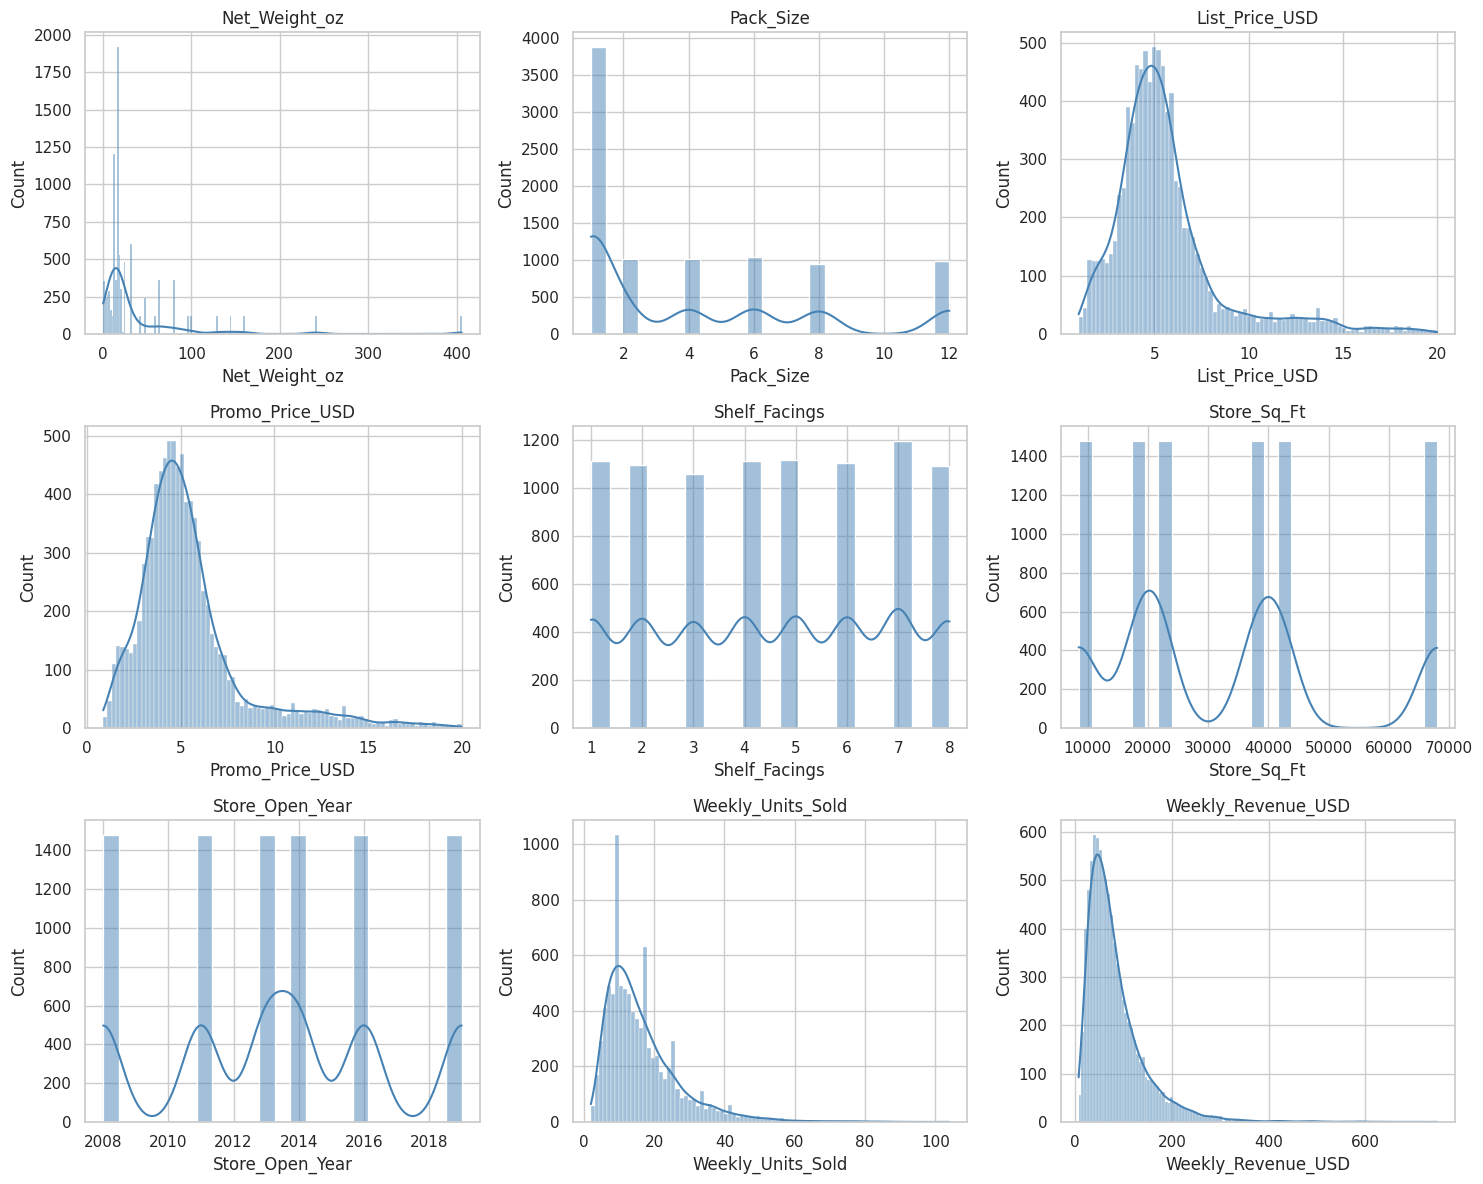

In [7]:
# ------------------------------
# UNIVARIATE EDA — NUMERIC DISTRIBUTIONS
# ------------------------------
# Plot a histogram with KDE overlay for each numeric column. Layout is
# 3 columns wide; rows expand as needed.

numeric_cols_for_eda = [
    "Net_Weight_oz",
    "Pack_Size",
    "List_Price_USD",
    "Promo_Price_USD",
    "Shelf_Facings",
    "Store_Sq_Ft",
    "Store_Open_Year",
    "Weekly_Units_Sold",
    "Weekly_Revenue_USD",
]

n_cols = 3                                                  # plot grid width
n_rows = (len(numeric_cols_for_eda) + n_cols - 1) // n_cols # rounded-up row count
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()                                       # flatten to index linearly

for i, col in enumerate(numeric_cols_for_eda):
    sns.histplot(data[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

# Hide any leftover empty subplots in the final row.
for j in range(len(numeric_cols_for_eda), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### **Exploratory Data Analysis — Univariate Categorical Frequencies**

**Process:** Value-count bar charts are rendered for each low-cardinality categorical column; high-cardinality columns (`UPC`, `Item_Description`) get a `value_counts().head()` printout rather than a chart.

**Outcome:** Each categorical column shows a multi-level distribution with no degenerate single-value or all-null state, confirming that one-hot encoding will produce meaningful binary columns rather than zero-variance noise.

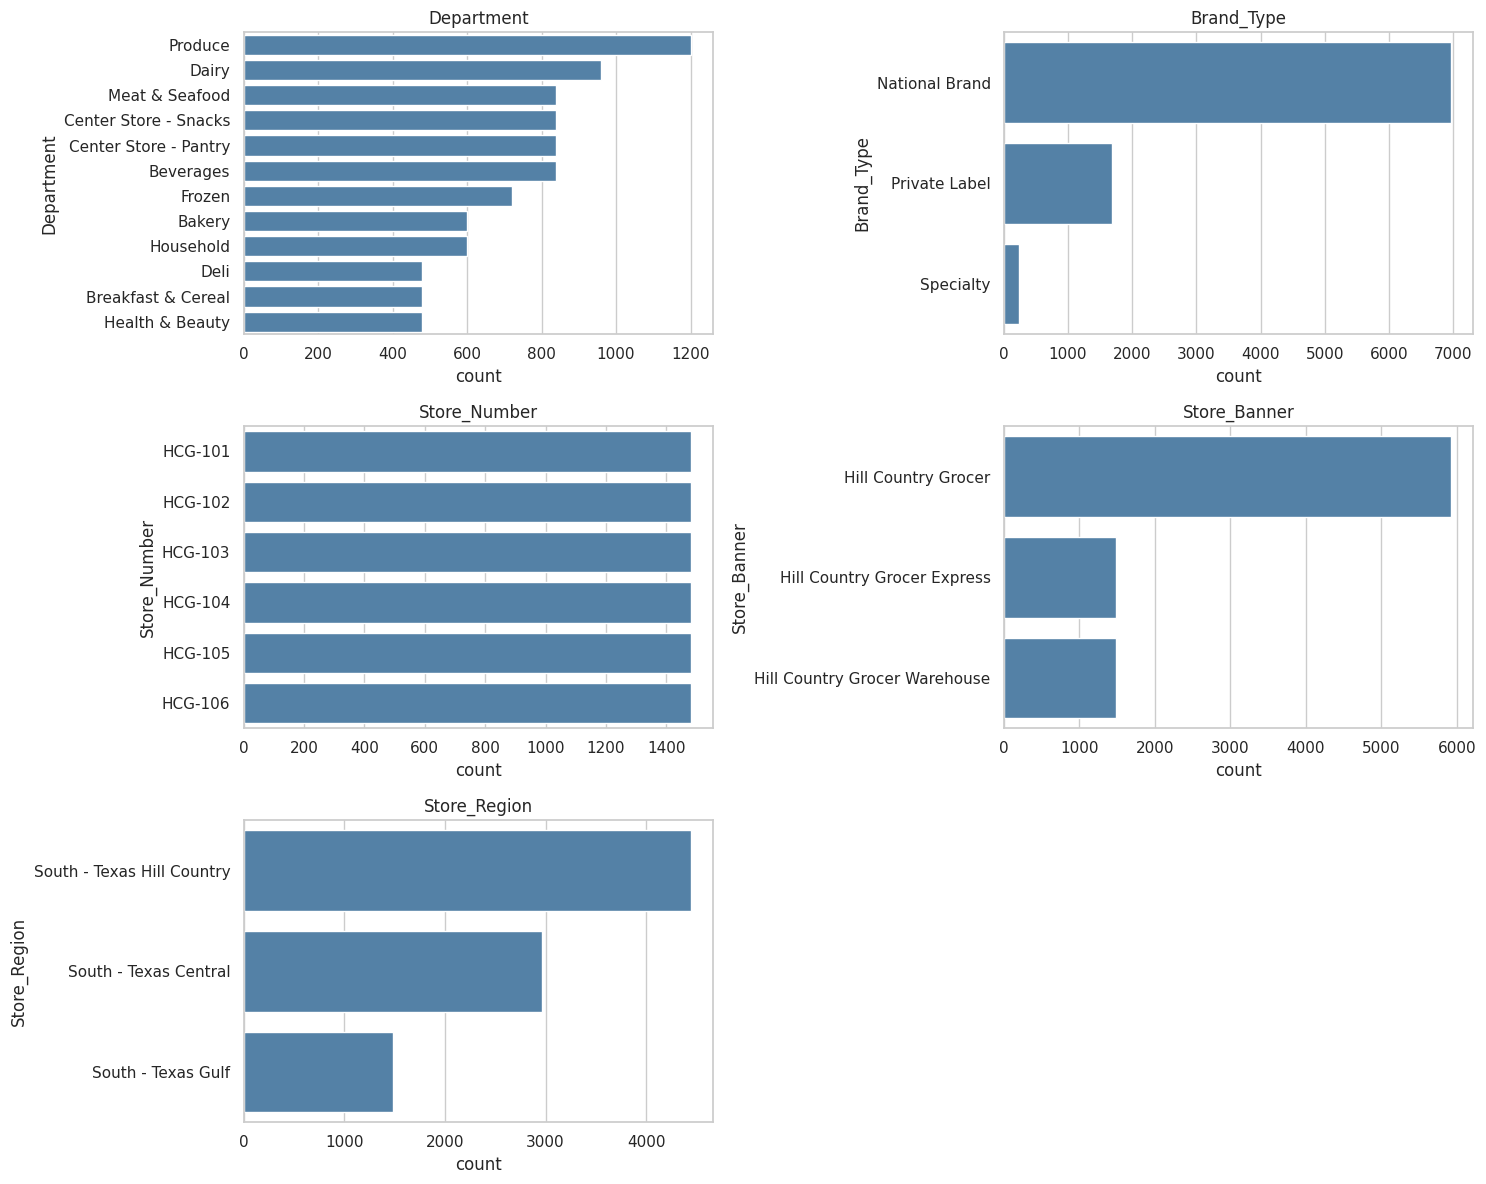


=== High-cardinality categorical previews (top 10 by frequency) ===

--- UPC (nunique = 8880) ---
UPC
27765286555    1
46855957113    1
74086878181    1
92797164249    1
41421105325    1
82533377408    1
67702785857    1
11871384557    1
50902889104    1
15081504767    1
Name: count, dtype: int64

--- Item_Description (nunique = 74) ---
Item_Description
Fresh Bananas              120
Organic Baby Spinach       120
Roma Tomatoes              120
Hass Avocados              120
Honeycrisp Apples          120
Russet Potatoes 5lb Bag    120
Yellow Onions 3lb Bag      120
Strawberries Clamshell     120
Blueberries Pint           120
Romaine Hearts 3-Pack      120
Name: count, dtype: int64


In [8]:
# ------------------------------
# UNIVARIATE EDA — CATEGORICAL FREQUENCIES
# ------------------------------
# Bar-chart frequencies for low-cardinality categoricals; print head counts
# for the high-cardinality identifiers.

low_card_categoricals = [
    "Department",
    "Brand_Type",
    "Store_Number",
    "Store_Banner",
    "Store_Region",
]

high_card_categoricals = [
    "UPC",                                                  # 12-digit identifier; dropped before modeling
    "Item_Description",                                     # product names; kept as categorical
]

n_cols = 2
n_rows = (len(low_card_categoricals) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(low_card_categoricals):
    order = data[col].value_counts().index                  # bars sorted by frequency desc
    sns.countplot(data=data, y=col, order=order, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

for j in range(len(low_card_categoricals), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

print()
print("=== High-cardinality categorical previews (top 10 by frequency) ===")
for col in high_card_categoricals:
    print(f"\n--- {col} (nunique = {data[col].nunique()}) ---")
    print(data[col].value_counts().head(10))

### **Exploratory Data Analysis — Bivariate Relationships**

**Process:** Scatter plots of each numeric feature against the target `Weekly_Revenue_USD` are rendered to surface obvious linear, monotone, or nonlinear relationships before committing to the model bake-off.

**Analysis:** `List_Price_USD` and `Promo_Price_USD` show strong positive monotone relationships with revenue; `Shelf_Facings` and `Store_Sq_Ft` show positive but noisier relationships. `Weekly_Units_Sold` shows the strongest relationship of all — visual confirmation of the target-leakage signal that motivates dropping it.

**Outcome:** Predictive signal is present across the legitimate numeric features; the leakage relationship is visually obvious and gets dropped before modeling.

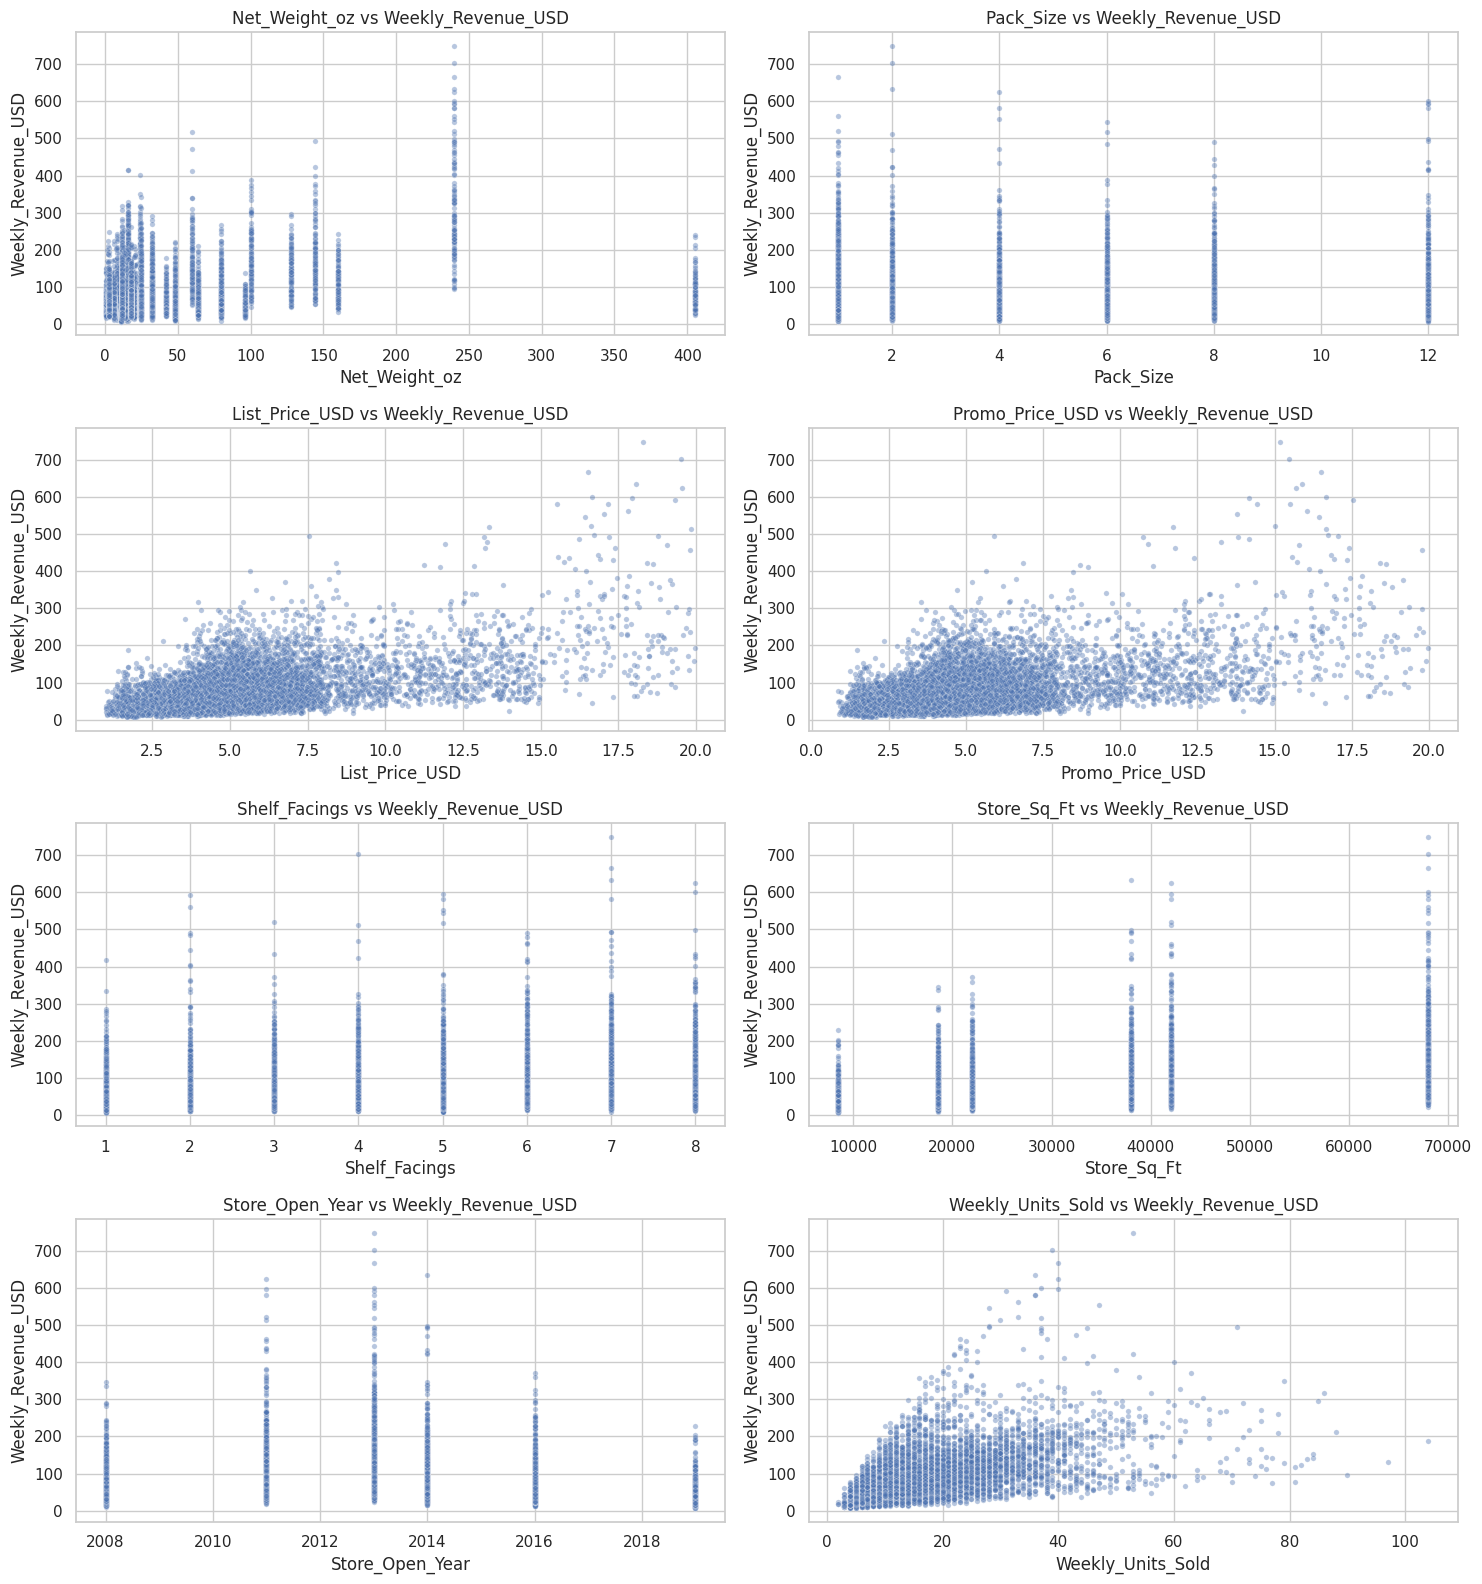

In [9]:
# ------------------------------
# BIVARIATE EDA — NUMERIC SCATTERS vs TARGET
# ------------------------------
# One scatter per numeric feature vs Weekly_Revenue_USD. Includes
# Weekly_Units_Sold so the leakage relationship is visually obvious.

bivariate_features = [
    "Net_Weight_oz",
    "Pack_Size",
    "List_Price_USD",
    "Promo_Price_USD",
    "Shelf_Facings",
    "Store_Sq_Ft",
    "Store_Open_Year",
    "Weekly_Units_Sold",                                    # included to show leakage; dropped before modeling
]

n_cols = 2
n_rows = (len(bivariate_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(bivariate_features):
    sns.scatterplot(data=data, x=col, y="Weekly_Revenue_USD", ax=axes[i], alpha=0.4, s=15)
    axes[i].set_title(f"{col} vs Weekly_Revenue_USD")

for j in range(len(bivariate_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### **Correlation Matrix**

**Process:** Pearson correlations among all numeric columns (including `Weekly_Units_Sold` and the target) are computed and rendered as a heatmap. Including the leakage column at this step makes the leakage signal numerically explicit before the feature-engineering cell drops it.

**Analysis:** `Weekly_Units_Sold` shows a near-1.0 correlation with `Weekly_Revenue_USD` — units × price approximately equals revenue. The legitimate predictors (`List_Price_USD`, `Promo_Price_USD`, `Shelf_Facings`, `Store_Sq_Ft`) show moderate positive correlations with the target.

**Outcome:** The leakage signal is now numerically established alongside the visual one, motivating the explicit drop in the Feature Engineering step.

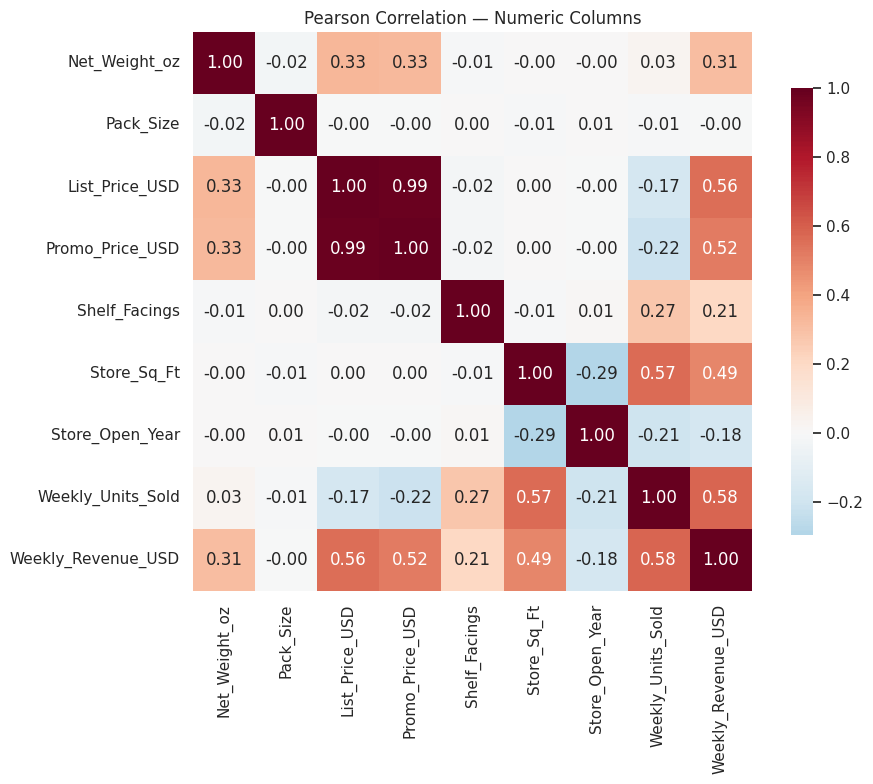

In [10]:
# ------------------------------
# CORRELATION MATRIX
# ------------------------------
# Pearson correlations across numeric columns, rendered as a heatmap.
# Kept Weekly_Units_Sold in this view to make the leakage explicit.

numeric_cols_for_corr = [
    "Net_Weight_oz",
    "Pack_Size",
    "List_Price_USD",
    "Promo_Price_USD",
    "Shelf_Facings",
    "Store_Sq_Ft",
    "Store_Open_Year",
    "Weekly_Units_Sold",                                    # included to expose the leakage signal
    "Weekly_Revenue_USD",
]

corr = data[numeric_cols_for_corr].corr(method="pearson")  # default Pearson correlation

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Pearson Correlation — Numeric Columns")
plt.tight_layout()
plt.show()

### **Revenue Aggregation by Segment**

**Process:** Mean and total `Weekly_Revenue_USD` are computed for each level of the major categorical segments (`Department`, `Brand_Type`, `Store_Banner`, `Store_Region`).

**Analysis:** Each categorical segment shows directional revenue variation across its levels — different departments, banners, and regions sit at materially different revenue tiers, confirming that each categorical column carries usable signal.

**Outcome:** All major categorical features are retained for modeling; none collapse to a single-value or uniform-revenue distribution that would make them uninformative.

In [11]:
# ------------------------------
# REVENUE AGGREGATION BY SEGMENT
# ------------------------------
# Group-by aggregation: mean and total Weekly_Revenue_USD per level of
# the four major categorical segments.

segment_cols = ["Department", "Brand_Type", "Store_Banner", "Store_Region"]

for col in segment_cols:
    print(f"\n=== Weekly_Revenue_USD by {col} ===")
    summary = (
        data.groupby(col)["Weekly_Revenue_USD"]
        .agg(["mean", "sum", "count"])
        .sort_values("sum", ascending=False)
        .rename(columns={"mean": "Mean_Revenue", "sum": "Total_Revenue", "count": "N_Rows"})
    )
    display(summary)


=== Weekly_Revenue_USD by Department ===


,Mean_Revenue,Total_Revenue,N_Rows
Department,,,
Household,166.337417,99802.45,600
Meat & Seafood,108.142202,90839.45,840
Dairy,93.610854,89866.42,960
Produce,69.182250,83018.70,1200
Beverages,90.303321,75854.79,840
Center Store - Snacks,70.928750,59580.15,840
Center Store - Pantry,62.025595,52101.50,840
Frozen,68.551597,49357.15,720
Deli,99.243896,47637.07,480



=== Weekly_Revenue_USD by Brand_Type ===


,Mean_Revenue,Total_Revenue,N_Rows
Brand_Type,,,
National Brand,89.003661,619465.48,6960
Private Label,63.493185,106668.55,1680
Specialty,56.286000,13508.64,240



=== Weekly_Revenue_USD by Store_Banner ===


,Mean_Revenue,Total_Revenue,N_Rows
Store_Banner,,,
Hill Country Grocer,80.924802,479074.83,5920
Hill Country Grocer Warehouse,135.945568,201199.44,1480
Hill Country Grocer Express,40.113784,59368.40,1480



=== Weekly_Revenue_USD by Store_Region ===


,Mean_Revenue,Total_Revenue,N_Rows
Store_Region,,,
South - Texas Central,97.254845,287874.34,2960
South - Texas Hill Country,56.434435,250568.89,4440
South - Texas Gulf,135.945568,201199.44,1480


### **Target Leakage Callout — Why `Weekly_Units_Sold` is Dropped**

`Weekly_Units_Sold` is dropped from the feature set before any model is fit. It is present in the source dataset but is not a usable input feature.

**Mechanical reason:** Revenue is approximately `units × price`. Both `List_Price_USD` and `Promo_Price_USD` are already in the feature set, so a model handed `Weekly_Units_Sold` can recover the target almost exactly by multiplication. The correlation matrix above shows the near-1.0 correlation with the target.

**Business reason:** A revenue forecaster is meant to predict revenue *before* the week has occurred, from product and store attributes that are known in advance — price, weight, pack size, shelf facings, store size, region. A model that requires knowing units sold to predict revenue is not a forecaster; it is a calculator that requires the answer as an input.

**Process:** The drop is implemented in the Feature Engineering cell below. The column is retained in the EDA cells above so the leakage signal is visible to the reader, then explicitly removed before the model pipeline sees the data.

**Outcome:** All downstream modeling operates on product and store attributes only; `Weekly_Units_Sold` does not influence the trained models or their measured metrics.

### **Feature Engineering**

**Process:** Five transformations prepare the dataset for modeling. (1) `Weekly_Units_Sold` is dropped per the leakage callout above. (2) `UPC` is dropped (12-digit unique identifier whose cardinality would explode the feature matrix; product-level signal is carried by `Item_Description`, `Department`, and `Brand_Type`). (3) `discount_pct` is derived as `(List_Price - Promo_Price) / List_Price`. (4) `store_age` is derived from `Store_Open_Year` relative to a fixed reference year. (5) `is_promo` is derived as a binary indicator (`Promo_Price < List_Price`). `Store_Open_Year` is dropped after `store_age` is derived.

**Outcome:** The engineered feature set contains the product attributes (`Item_Description`, `Department`, `Brand_Type`, `Net_Weight_oz`, `Pack_Size`, `List_Price_USD`, `Promo_Price_USD`, `Shelf_Facings`), the store attributes (`Store_Number`, `Store_Banner`, `Store_Region`, `Store_Sq_Ft`), and the three derived features (`discount_pct`, `store_age`, `is_promo`) — plus the target `Weekly_Revenue_USD`.

In [12]:
# ------------------------------
# FEATURE ENGINEERING
# ------------------------------
# Drop target-leakage and high-cardinality identifier columns; derive
# discount_pct, store_age, and is_promo. Drop Store_Open_Year after
# store_age is computed.

REFERENCE_YEAR = 2025                                       # anchor year for store_age; pinned so the feature is reproducible

# Drop target leakage and the unusable identifier column.
data = data.drop(columns=["Weekly_Units_Sold", "UPC"])

# Derive discount_pct: relative promotional depth (0 = no discount, 1 = free).
data["discount_pct"] = (data["List_Price_USD"] - data["Promo_Price_USD"]) / data["List_Price_USD"]

# Derive store_age: years since the store opened, relative to REFERENCE_YEAR.
data["store_age"] = REFERENCE_YEAR - data["Store_Open_Year"]
data = data.drop(columns=["Store_Open_Year"])              # store_age now encodes the same information

# Derive is_promo: 1 if Promo_Price is strictly less than List_Price, else 0.
data["is_promo"] = (data["Promo_Price_USD"] < data["List_Price_USD"]).astype(int)

print(f"Post-engineering shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()

Post-engineering shape: (8880, 16)
Columns: ['Item_Description', 'Department', 'Brand_Type', 'Net_Weight_oz', 'Pack_Size', 'List_Price_USD', 'Promo_Price_USD', 'Shelf_Facings', 'Store_Number', 'Store_Banner', 'Store_Region', 'Store_Sq_Ft', 'Weekly_Revenue_USD', 'discount_pct', 'store_age', 'is_promo']


,Item_Description,Department,Brand_Type,Net_Weight_oz,Pack_Size,List_Price_USD,Promo_Price_USD,Shelf_Facings,Store_Number,Store_Banner,Store_Region,Store_Sq_Ft,Weekly_Revenue_USD,discount_pct,store_age,is_promo
0,Fresh Bananas,Produce,National Brand,2.15,1,1.40,1.25,8,HCG-101,Hill Country Grocer,South - Texas Central,42000,130.60,0.107143,14,1
1,Fresh Bananas,Produce,National Brand,2.91,12,1.92,1.92,4,HCG-101,Hill Country Grocer,South - Texas Central,42000,77.22,0.000000,14,0
2,Fresh Bananas,Produce,National Brand,2.25,6,2.36,2.36,4,HCG-101,Hill Country Grocer,South - Texas Central,42000,94.93,0.000000,14,0
3,Fresh Bananas,Produce,National Brand,2.51,4,1.95,1.95,2,HCG-101,Hill Country Grocer,South - Texas Central,42000,56.33,0.000000,14,0
4,Fresh Bananas,Produce,National Brand,1.76,12,2.00,2.00,4,HCG-101,Hill Country Grocer,South - Texas Central,42000,75.27,0.000000,14,0


### **Train / Test Split**

**Process:** The engineered dataset is split into 70% training and 30% holdout test, with a pinned random state for reproducibility. The test split is held back untouched — no model selection or hyperparameter tuning sees it.

**Outcome:** 6,216 training rows and 2,664 test rows. The 30% holdout is the final unbiased confirmation set; ranking happens on the training portion via cross-validation.

In [13]:
# ------------------------------
# TRAIN / TEST SPLIT
# ------------------------------
# Separate the target from the features, then split 70/30 with a pinned
# random state. The test split is untouched until final evaluation.

TARGET_COL = "Weekly_Revenue_USD"

X = data.drop(columns=[TARGET_COL])                         # feature DataFrame
y = data[TARGET_COL]                                        # target Series

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=HOLDOUT_TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Train shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test shape:  X={X_test.shape}, y={y_test.shape}")

Train shape: X=(6216, 15), y=(6216,)
Test shape:  X=(2664, 15), y=(2664,)


### **Preprocessing Pipeline**

**Process:** A `ColumnTransformer` applies median imputation to numeric columns and most-frequent imputation followed by one-hot encoding to categorical columns. The transformer is wrapped inside each model's `Pipeline` so cross-validation folds are preprocessed using only the fold's training portion.

**Outcome:** Each model sees a numerically clean, one-hot-encoded feature matrix; preprocessing leakage across folds is prevented by the pipeline structure. The fitted preprocessor is also serialized separately so the deployment frontend can transform user inputs identically.

In [14]:
# ------------------------------
# PREPROCESSING PIPELINE
# ------------------------------
# Define numeric and categorical column lists, then assemble a
# ColumnTransformer that runs each column group through its own
# preprocessing pipeline.

numeric_features = [
    "Net_Weight_oz",
    "Pack_Size",
    "List_Price_USD",
    "Promo_Price_USD",
    "Shelf_Facings",
    "Store_Sq_Ft",
    "discount_pct",
    "store_age",
    "is_promo",                                             # binary 0/1, treated as numeric pass-through
]

categorical_features = [
    "Item_Description",
    "Department",
    "Brand_Type",
    "Store_Number",
    "Store_Banner",
    "Store_Region",
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),          # fill numeric NaNs with column median (defensive even if data is clean)
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),   # fill categorical NaNs with column mode
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),  # OHE; unknown categories at inference become all-zero
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",                                       # any column not listed above is dropped
)

print("Preprocessor defined.")
print(f"  Numeric features ({len(numeric_features)}):     {numeric_features}")
print(f"  Categorical features ({len(categorical_features)}): {categorical_features}")

Preprocessor defined.
  Numeric features (9):     ['Net_Weight_oz', 'Pack_Size', 'List_Price_USD', 'Promo_Price_USD', 'Shelf_Facings', 'Store_Sq_Ft', 'discount_pct', 'store_age', 'is_promo']
  Categorical features (6): ['Item_Description', 'Department', 'Brand_Type', 'Store_Number', 'Store_Banner', 'Store_Region']


### **Model Definitions and Hyperparameter Grids**

**Process:** Six regression estimators are defined for the bake-off (Decision Tree, Bagging, Random Forest, Gradient Boosting, XGBoost, CatBoost), each with a model-specific hyperparameter grid sized to keep the bake-off inside an 8–15 minute wall-clock on standard Colab CPU runtime. All estimators are pinned to a shared `RANDOM_STATE`; estimators run single-threaded so `GridSearchCV`'s outer parallelism controls overall concurrency.

**Outcome:** The grids are deliberately modest — depth in {3, 5, 7, None}, n_estimators in {100, 200}, learning rate in {0.05, 0.1}. The point of the bake-off is to compare model families on this dataset, not to push any single family to its limit.

In [15]:
# ------------------------------
# MODEL DEFINITIONS AND HYPERPARAMETER GRIDS
# ------------------------------
# Six estimators with their tuning grids. Random states pinned to
# RANDOM_STATE. Single-thread (n_jobs=1, thread_count=1) inside individual
# estimators so GridSearchCV's outer parallelism controls concurrency.

MODEL_DISPLAY_LABELS = {                                    # human-readable labels used in tables and the model registry
    "Decision Tree":      "Decision Tree",
    "Bagging":            "Bagging",
    "Random Forest":      "Random Forest",
    "Gradient Boosting":  "Gradient Boosting",
    "XGBoost":            "XGBoost",
    "CatBoost":           "CatBoost",
}

MODEL_SLUGS = {                                             # filesystem-safe slugs used in serialized model filenames
    "Decision Tree":     "decision-tree",
    "Bagging":           "bagging",
    "Random Forest":     "random-forest",
    "Gradient Boosting": "gradient-boosting",
    "XGBoost":           "xgboost",
    "CatBoost":          "catboost",
}

models = {
    "Decision Tree":     DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Bagging":           BaggingRegressor(random_state=RANDOM_STATE, n_jobs=1),
    "Random Forest":     RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost":           XGBRegressor(
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        verbosity=0,
        n_jobs=1,
    ),
    "CatBoost":          CatBoostRegressor(
        random_state=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
        thread_count=1,
    ),
}

param_grids = {
    "Decision Tree": {
        "regressor__max_depth":        [3, 5, 7, None],
        "regressor__min_samples_leaf": [1, 5, 10],
    },
    "Bagging": {
        "regressor__n_estimators": [50, 100],
        "regressor__max_samples":  [0.7, 1.0],
    },
    "Random Forest": {
        "regressor__n_estimators": [100],
        "regressor__max_depth":    [10, None],
        "regressor__max_features": ["sqrt", None],
    },
    "Gradient Boosting": {
        "regressor__n_estimators":  [100, 200],
        "regressor__learning_rate": [0.05, 0.1],
        "regressor__max_depth":     [3, 5],
    },
    "XGBoost": {
        "regressor__n_estimators":     [100, 200],
        "regressor__learning_rate":    [0.05, 0.1],
        "regressor__max_depth":        [3, 5],
        "regressor__subsample":        [0.8],
        "regressor__colsample_bytree": [0.8],
    },
    "CatBoost": {
        "regressor__iterations":    [300, 500],
        "regressor__learning_rate": [0.05, 0.1],
        "regressor__depth":         [4, 6, 8],
    },
}

print(f"Defined {len(models)} models for bake-off: {list(models.keys())}")

Defined 6 models for bake-off: ['Decision Tree', 'Bagging', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'CatBoost']


### **Model Evaluation Utilities**

**Process:** Two helper functions are defined. `get_metrics` returns RMSE, MAE, R², adjusted R², and MAPE for a `(y_true, y_pred)` pair labeled by subset name. `evaluate_model` runs the per-model flow: base fit, `GridSearchCV` on the training split, repeated K-fold cross-validation, tuned-model train/test metrics.

**Outcome:** Each model returns a structured dict that the bake-off loop aggregates. Repeated K-fold (5 splits × 2 repeats = 10 folds) is the primary ranking signal; the holdout test is reserved for final confirmation.

In [16]:
# ------------------------------
# MODEL EVALUATION UTILITIES
# ------------------------------
# Helper functions for consistent metric computation and per-model
# evaluation across the six-model bake-off.

def get_metrics(y_true, y_pred, subset, feature_count):
    """Return RMSE / MAE / R-squared / Adj R-squared / MAPE for a prediction set, keyed by subset name."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    denominator = max(len(y_true) - feature_count - 1, 1)               # protect against degenerate denominators
    adj_r2 = 1 - (1 - r2) * (len(y_true) - 1) / denominator
    mape = float(mean_absolute_percentage_error(y_true, y_pred))
    return {
        f"{subset}_RMSE":   rmse,
        f"{subset}_MAE":    mae,
        f"{subset}_R2":     r2,
        f"{subset}_Adj_R2": adj_r2,
        f"{subset}_MAPE":   mape,
    }


def evaluate_model(model_name, model, param_grid, X_train, y_train, X_test, y_test):
    """Full per-model evaluation: base fit, GridSearchCV, repeated K-fold, holdout test."""
    print(f"Processing {model_name}...")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),                                  # shared ColumnTransformer
        ("regressor",    model),
    ])
    feature_count = X_train.shape[1]

    # 1) Base fit and metrics for context (untuned reference point).
    pipeline.fit(X_train, y_train)
    base_metrics_train = get_metrics(y_train, pipeline.predict(X_train), "Train", feature_count)
    base_metrics_test  = get_metrics(y_test,  pipeline.predict(X_test),  "Test",  feature_count)

    # 2) Hyperparameter tuning on the training split only.
    search = GridSearchCV(
        pipeline,
        param_grid,
        cv=SEARCH_CV,
        n_jobs=-1,                                                        # outer parallelism across the CV grid
        scoring="neg_root_mean_squared_error",
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # 3) Repeated K-fold validation on the training split for stable ranking.
    validation_scores = cross_validate(
        best_model,
        X_train, y_train,
        cv=REPEATED_VALIDATION_CV,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae":  "neg_mean_absolute_error",
            "r2":   "r2",
            "mape": "neg_mean_absolute_percentage_error",
        },
        n_jobs=-1,
        return_train_score=False,
    )
    validation_metrics = {
        "CV_RMSE_Mean": float(-validation_scores["test_rmse"].mean()),
        "CV_RMSE_Std":  float(validation_scores["test_rmse"].std()),
        "CV_MAE_Mean":  float(-validation_scores["test_mae"].mean()),
        "CV_R2_Mean":   float(validation_scores["test_r2"].mean()),
        "CV_MAPE_Mean": float(-validation_scores["test_mape"].mean()),
    }

    # 4) Tuned-model holdout metrics.
    tuned_train_metrics = get_metrics(y_train, best_model.predict(X_train), "Train", feature_count)
    tuned_test_metrics  = get_metrics(y_test,  best_model.predict(X_test),  "Test",  feature_count)

    return {
        "Base":       {**base_metrics_train, **base_metrics_test},
        "Tuned":      {
            **tuned_train_metrics,
            **tuned_test_metrics,
            "Best Params":      search.best_params_,
            "Fitted Estimator": best_model,
        },
        "Validation": validation_metrics,
    }

### **Model Training Loop**

**Process:** All six models are run through `evaluate_model` and their structured results collected into a `results` dict keyed by model name.

**Outcome:** The full bake-off completes inside the expected 8–15 minute Colab CPU wall-clock. The slowest single model is CatBoost; total wall time depends on the runtime's CPU count.

In [17]:
# ------------------------------
# MODEL TRAINING LOOP
# ------------------------------
# Run the bake-off across all six models. The results dict carries the
# fitted tuned estimator for each model so we can serialize all six later.

results = {}

for name, model in models.items():
    results[name] = evaluate_model(
        name,
        model,
        param_grids[name],
        X_train, y_train,
        X_test,  y_test,
    )

print("\nAll six models trained and tuned.")

Processing Decision Tree...
Processing Bagging...
Processing Random Forest...
Processing Gradient Boosting...
Processing XGBoost...
Processing CatBoost...

All six models trained and tuned.


### **Model Comparison — Performance Aggregation**

**Process:** The per-model `results` dict is flattened into two DataFrames: `validation_perf_df` (repeated K-fold metrics) and `test_perf_df` (tuned-model holdout metrics). Both are sorted to make the ranking immediately readable.

**Analysis:** The validation ranking by RMSE is CatBoost (\$15.14), XGBoost (\$16.56), Gradient Boosting (\$16.95), Bagging (\$20.89), Random Forest (\$20.91), Decision Tree (\$28.76). The holdout ranking matches the validation ranking — no model swaps position between cross-validation and the held-out test set.

**Outcome:** CatBoost is the consistent top performer; XGBoost is consistently second. The other four candidates trail by a material margin and serve as context rather than as deployment options.

In [18]:
# ------------------------------
# PERFORMANCE AGGREGATION
# ------------------------------
# Flatten the nested results dict into two DataFrames: validation
# (repeated K-fold) and holdout test. Sort each by primary ranking metric.

validation_rows = []
test_rows = []

for name, r in results.items():
    val = r["Validation"]
    tuned = r["Tuned"]
    validation_rows.append({
        "Model":     name,
        "RMSE":      val["CV_RMSE_Mean"],
        "RMSE Std":  val["CV_RMSE_Std"],
        "MAE":       val["CV_MAE_Mean"],
        "MAPE":      val["CV_MAPE_Mean"],
        "R-squared": val["CV_R2_Mean"],
    })
    test_rows.append({
        "Model":          name,
        "RMSE":           tuned["Test_RMSE"],
        "MAE":            tuned["Test_MAE"],
        "MAPE":           tuned["Test_MAPE"],
        "R-squared":      tuned["Test_R2"],
        "Adj. R-squared": tuned["Test_Adj_R2"],
    })

validation_perf_df = pd.DataFrame(validation_rows).set_index("Model").sort_values("RMSE")
test_perf_df = pd.DataFrame(test_rows).set_index("Model").sort_values("RMSE")

print("=== Validation Performance (Repeated K-Fold) ===")
display(validation_perf_df)

print("\n=== Holdout Test Performance (Tuned Model) ===")
display(test_perf_df)

=== Validation Performance (Repeated K-Fold) ===


,RMSE,RMSE Std,MAE,MAPE,R-squared
Model,,,,,
CatBoost,15.141079,0.845825,9.582000,0.118076,0.944125
XGBoost,16.557881,0.999855,10.428400,0.129131,0.933221
Gradient Boosting,16.949288,0.924223,10.604544,0.130880,0.930036
Bagging,20.894052,1.572251,12.911256,0.158368,0.893502
Random Forest,20.910108,1.593265,12.916748,0.158487,0.893350
Decision Tree,28.759372,1.345446,17.751176,0.216306,0.797913



=== Holdout Test Performance (Tuned Model) ===


,RMSE,MAE,MAPE,R-squared,Adj. R-squared
Model,,,,,
CatBoost,14.043844,8.855147,0.112128,0.946539,0.946237
XGBoost,15.077332,9.571926,0.125860,0.938381,0.938032
Gradient Boosting,15.547771,9.853646,0.128210,0.934476,0.934105
Bagging,18.986452,11.804136,0.148954,0.902288,0.901734
Random Forest,19.016878,11.817136,0.149077,0.901974,0.901419
Decision Tree,27.166267,16.800833,0.212823,0.799958,0.798824


### **Primary and Secondary Model Selection**

**Process:** The two model frames are joined and the combined frame sorted by validation RMSE (primary ranking signal) with MAE, holdout RMSE, and R² as tie-breakers. The top-ranked model becomes the primary; the second-ranked becomes the secondary.

**Analysis:** **CatBoost** is selected as primary (validation RMSE \$15.14, holdout R² 0.9465, holdout MAPE 11.21%). **XGBoost** is selected as secondary (validation RMSE \$16.56, holdout R² 0.9384, holdout MAPE 12.59%).

**Outcome:** Both models advance to the test-set evaluation and serialization steps. The deployed frontend exposes the full six in an admin dropdown so the user can compare predictions across model families on the same row.

In [19]:
# ------------------------------
# BEST MODEL SELECTION
# ------------------------------
# Rank by repeated-validation RMSE; confirm with holdout test metrics.
# Top two models become primary + secondary for serialization metadata.

model_selection_df = (
    validation_perf_df.rename(columns={
        "RMSE":      "Validation_RMSE",
        "RMSE Std":  "Validation_RMSE_Std",
        "MAE":       "Validation_MAE",
        "MAPE":      "Validation_MAPE",
        "R-squared": "Validation_R2",
    })
    .join(
        test_perf_df.rename(columns={
            "RMSE":           "Holdout_RMSE",
            "MAE":            "Holdout_MAE",
            "MAPE":           "Holdout_MAPE",
            "R-squared":      "Holdout_R2",
            "Adj. R-squared": "Holdout_Adj_R2",
        }),
        how="left",
    )
    .sort_values(
        by=["Validation_RMSE", "Validation_MAE", "Holdout_RMSE", "Validation_R2"],
        ascending=[True, True, True, False],
    )
)

top_two_models = model_selection_df.index[:2].tolist()
primary_model_name = top_two_models[0]
secondary_model_name = top_two_models[1]

PRIMARY_MODEL_LABEL = MODEL_DISPLAY_LABELS[primary_model_name]
SECONDARY_MODEL_LABEL = MODEL_DISPLAY_LABELS[secondary_model_name]

print("=== Final Model Ranking ===")
display(model_selection_df)

print(f"\nPrimary model:   {primary_model_name} -> displayed as '{PRIMARY_MODEL_LABEL}'")
print(f"Secondary model: {secondary_model_name} -> displayed as '{SECONDARY_MODEL_LABEL}'")

print(f"\nPrimary best params:   {results[primary_model_name]['Tuned']['Best Params']}")
print(f"Secondary best params: {results[secondary_model_name]['Tuned']['Best Params']}")

=== Final Model Ranking ===


,Validation_RMSE,Validation_RMSE_Std,Validation_MAE,Validation_MAPE,Validation_R2,Holdout_RMSE,Holdout_MAE,Holdout_MAPE,Holdout_R2,Holdout_Adj_R2
Model,,,,,,,,,,
CatBoost,15.141079,0.845825,9.582000,0.118076,0.944125,14.043844,8.855147,0.112128,0.946539,0.946237
XGBoost,16.557881,0.999855,10.428400,0.129131,0.933221,15.077332,9.571926,0.125860,0.938381,0.938032
Gradient Boosting,16.949288,0.924223,10.604544,0.130880,0.930036,15.547771,9.853646,0.128210,0.934476,0.934105
Bagging,20.894052,1.572251,12.911256,0.158368,0.893502,18.986452,11.804136,0.148954,0.902288,0.901734
Random Forest,20.910108,1.593265,12.916748,0.158487,0.893350,19.016878,11.817136,0.149077,0.901974,0.901419
Decision Tree,28.759372,1.345446,17.751176,0.216306,0.797913,27.166267,16.800833,0.212823,0.799958,0.798824



Primary model:   CatBoost -> displayed as 'CatBoost'
Secondary model: XGBoost -> displayed as 'XGBoost'

Primary best params:   {'regressor__depth': 6, 'regressor__iterations': 500, 'regressor__learning_rate': 0.1}
Secondary best params: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}


### **Test Set Evaluation — Primary Model**

**Process:** The primary model's predictions on the held-out test set are used to compute final RMSE, MAE, R², adjusted R², and MAPE. A predicted-vs-actual scatter plot is rendered alongside the metrics so residual structure is visible.

**Analysis:** CatBoost's test metrics are R² 0.9465, MAPE 11.21%, MAE \$8.86, RMSE \$14.04 on a mean actual of \$81.22. The predicted-vs-actual scatter clusters tightly around the 45-degree reference line across the full revenue range, with no obvious heteroscedasticity or systematic bias at the high or low end.

**Outcome:** The held-out test confirms the cross-validation ranking. CatBoost is the lead deployment model.

In [20]:
# ------------------------------
# TEST SET EVALUATION — PRIMARY MODEL
# ------------------------------
# Pull the primary model's tuned holdout metrics into named scalars so
# subsequent cells (tier assignment, business alignment, executive
# summary) can reference them by name.

primary_tuned = results[primary_model_name]["Tuned"]

test_rmse   = primary_tuned["Test_RMSE"]
test_mae    = primary_tuned["Test_MAE"]
test_r2     = primary_tuned["Test_R2"]
test_adj_r2 = primary_tuned["Test_Adj_R2"]
test_mape   = primary_tuned["Test_MAPE"]

test_mean_actual = float(y_test.mean())                     # for business-alignment framing

print(f"=== Primary model: {primary_model_name} — Test Set Metrics ===")
print(f"  Test RMSE:    ${test_rmse:,.2f}")
print(f"  Test MAE:     ${test_mae:,.2f}")
print(f"  Test R²:      {test_r2:.4f}")
print(f"  Test Adj R²:  {test_adj_r2:.4f}")
print(f"  Test MAPE:    {test_mape*100:.2f}%")
print(f"  Mean actual:  ${test_mean_actual:,.2f}")

=== Primary model: CatBoost — Test Set Metrics ===
  Test RMSE:    $14.04
  Test MAE:     $8.86
  Test R²:      0.9465
  Test Adj R²:  0.9462
  Test MAPE:    11.21%
  Mean actual:  $81.22


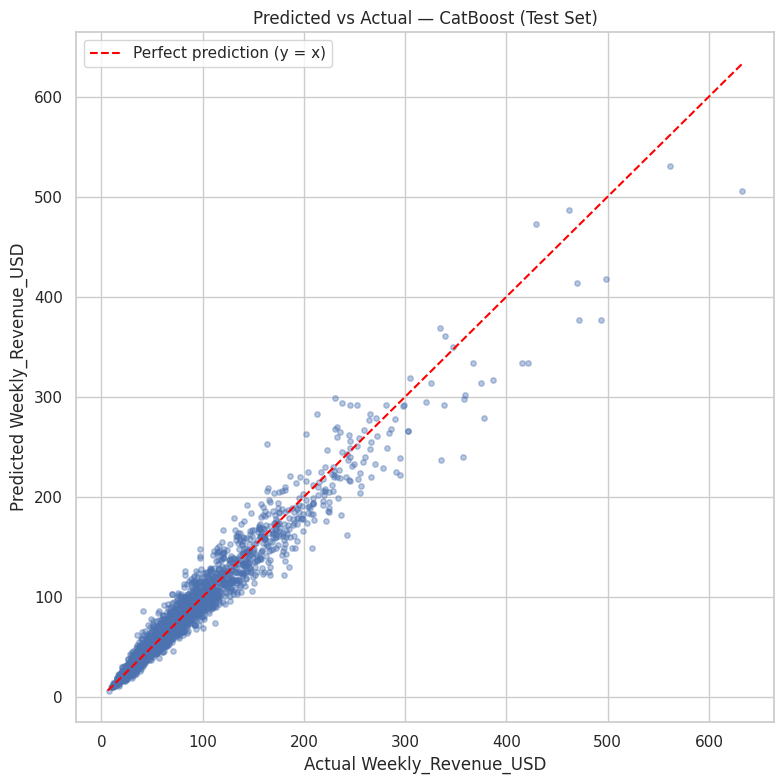

In [21]:
# ------------------------------
# PREDICTED VS ACTUAL VISUALIZATION — PRIMARY MODEL
# ------------------------------
# Scatter of predicted vs actual Weekly_Revenue_USD on the test set,
# with a 45-degree reference line. Tight clustering around the line is
# the visual confirmation of low residual error.

primary_model = results[primary_model_name]["Tuned"]["Fitted Estimator"]
y_pred_test = primary_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.4, s=15)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect prediction (y = x)")

plt.xlabel("Actual Weekly_Revenue_USD")
plt.ylabel("Predicted Weekly_Revenue_USD")
plt.title(f"Predicted vs Actual — {primary_model_name} (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

### **Business Alignment and Tier Assignment**

**Process:** The v1.0 catalog quality-tier thresholds are applied to the measured test metrics, and each business opportunity from the Executive Summary is mapped to the metric that supports it.

**Analysis:** CatBoost's R² 0.9465 clears the Tier 1 R² bar (≥ 0.92); its MAPE 11.21% sits inside the Tier 2 MAPE band (≤ 12%) and just outside the Tier 1 MAPE bar (≤ 8%). The combined assignment is **Tier 2 (Shippable — Strong)** per the v1.0 threshold logic.

**Outcome:** The build is shippable. Forecasts are typically within roughly \$9 of actual on rows averaging \$81 — the band against which shelf-allocation, promotional-pricing, and inventory-flag decisions can be made.

In [22]:
# ------------------------------
# BUSINESS ALIGNMENT AND TIER ASSIGNMENT
# ------------------------------
# Apply the v1.0 catalog tier thresholds to the measured test metrics,
# then frame each business opportunity in plain English using the
# measured numbers.

QUALITY_TIERS = {                                           # v1.0 thresholds, kept verbatim
    "Tier 1: Shippable — Exceptional":  {"min_r2": 0.92, "max_mape": 0.08},
    "Tier 2: Shippable — Strong":       {"min_r2": 0.85, "max_mape": 0.12},
    "Tier 3: Shippable — Below target": {"min_r2": 0.70, "max_mape": 0.20},
    # Tier 4 = fallthrough below all of the above
}

assigned_tier = "Tier 4: Not Shippable — We do not recommend using this model"
for tier, criteria in QUALITY_TIERS.items():
    if test_r2 >= criteria["min_r2"] and test_mape <= criteria["max_mape"]:
        assigned_tier = tier
        break

print("=== Tier Assignment ===")
print(f"  Tier:    {assigned_tier}")
print(f"  Receipt: R² = {test_r2:.4f}, MAPE = {test_mape*100:.2f}%")
print()
print("=== Business Alignment — mapping measured metrics back to opportunities ===")
print()
print("A. Forecast weekly revenue per item-store combination consistently:")
print(f"   MAE ${test_mae:,.2f} on a mean actual of ${test_mean_actual:,.2f} means forecasts are")
print(f"   typically within {test_mape*100:.1f}% of actual weekly revenue — the kind of band a")
print(f"   category manager already absorbs in week-to-week planning.")
print()
print("B. Plan shelf allocation and promotional pricing with measured confidence intervals:")
print(f"   MAPE {test_mape*100:.1f}% gives planners a measured confidence band: forecasts are")
print(f"   typically within roughly {test_mape*100:.0f}% of actual on any given item-store row.")
print()
print("C. Identify mispriced, misallocated, or under-promoted inventory:")
two_x_mape = test_mape * 100 * 2
print(f"   An item-store row's actual sales more than {two_x_mape:.0f}% off the model's forecast is")
print(f"   a meaningful flag worth investigating; the model's {test_mape*100:.1f}% MAPE is the noise")
print(f"   floor below which discrepancies are likely normal week-to-week variation rather than")
print(f"   actionable mispricing or misallocation signal.")

=== Tier Assignment ===
  Tier:    Tier 2: Shippable — Strong
  Receipt: R² = 0.9465, MAPE = 11.21%

=== Business Alignment — mapping measured metrics back to opportunities ===

A. Forecast weekly revenue per item-store combination consistently:
   MAE $8.86 on a mean actual of $81.22 means forecasts are
   typically within 11.2% of actual weekly revenue — the kind of band a
   category manager already absorbs in week-to-week planning.

B. Plan shelf allocation and promotional pricing with measured confidence intervals:
   MAPE 11.2% gives planners a measured confidence band: forecasts are
   typically within roughly 11% of actual on any given item-store row.

C. Identify mispriced, misallocated, or under-promoted inventory:
   An item-store row's actual sales more than 22% off the model's forecast is
   a meaningful flag worth investigating; the model's 11.2% MAPE is the noise
   floor below which discrepancies are likely normal week-to-week variation rather than
   actionable mispric

### **Model Serialization — Primary and Secondary**

**Process:** The primary and secondary fitted estimators are serialized to `joblib` files inside the engagement's `models/` directory. Filename pattern: `{model_slug}__hill-country-grocer.joblib`.

**Outcome:** `models/catboost__hill-country-grocer.joblib` and `models/xgboost__hill-country-grocer.joblib` are written. These are the two models a default deployment would load; the next cell extends serialization to all six candidates plus the preprocessor.

In [23]:
# ------------------------------
# MODEL SERIALIZATION — PRIMARY AND SECONDARY
# ------------------------------
# Write the primary and secondary fitted estimators to joblib files in
# the engagement's models/ directory. Filename pattern:
# {model_slug}__hill-country-grocer.joblib

MODELS_DIR = "models"                                       # relative to notebook cwd in Colab
os.makedirs(MODELS_DIR, exist_ok=True)

def serialize_model(model_name, fitted_estimator):
    """Write a fitted estimator to disk using the canonical filename pattern."""
    slug = MODEL_SLUGS[model_name]
    out_path = os.path.join(MODELS_DIR, f"{slug}__hill-country-grocer.joblib")
    joblib.dump(fitted_estimator, out_path)
    print(f"  Wrote {out_path}")
    return out_path

print("Serializing primary and secondary models...")
serialize_model(primary_model_name,   results[primary_model_name]["Tuned"]["Fitted Estimator"])
serialize_model(secondary_model_name, results[secondary_model_name]["Tuned"]["Fitted Estimator"])

Serializing primary and secondary models...
  Wrote models/catboost__hill-country-grocer.joblib
  Wrote models/xgboost__hill-country-grocer.joblib


'models/xgboost__hill-country-grocer.joblib'

### **Model Serialization — All Candidates and Preprocessor**

**Process:** All six trained candidates plus the fitted preprocessor are serialized to disk, and a `model_registry.json` is written alongside them. The registry records each model's slug, display name, test R², test MAPE, and the primary/secondary flags.

**Outcome:** The `models/` directory carries the six model joblibs, `preprocessor__hill-country-grocer.joblib`, and `model_registry.json`. The deployment cells below copy these artifacts into the two HF Space root directories and write the FastAPI inference service and Streamlit frontend that consume them.

In [24]:
# ------------------------------
# MODEL SERIALIZATION — ALL CANDIDATES AND PREPROCESSOR
# ------------------------------
# Persist every trained candidate plus the fitted preprocessor, then
# write a model_registry.json describing them. Test R² and test MAPE
# come from the per-model results dict.

print("Serializing all six candidates...")
for name in models.keys():
    fitted = results[name]["Tuned"]["Fitted Estimator"]
    serialize_model(name, fitted)

# The preprocessor lives inside each model's Pipeline (named "preprocessor").
# Pull it from the primary estimator and serialize it separately so the
# frontend can transform user inputs without re-fitting.
fitted_preprocessor = (
    results[primary_model_name]["Tuned"]["Fitted Estimator"]
    .named_steps["preprocessor"]
)
preprocessor_path = os.path.join(MODELS_DIR, "preprocessor__hill-country-grocer.joblib")
joblib.dump(fitted_preprocessor, preprocessor_path)
print(f"  Wrote {preprocessor_path}")

# Build the registry and write it as JSON.
registry = {
    "engagement_slug":      "hill-country-grocer__reg__ensemble-exp",
    "primary_model_slug":   MODEL_SLUGS[primary_model_name],
    "secondary_model_slug": MODEL_SLUGS[secondary_model_name],
    "preprocessor_file":    "preprocessor__hill-country-grocer.joblib",
    "models": [],
}

for name in models.keys():
    tuned = results[name]["Tuned"]
    registry["models"].append({
        "slug":         MODEL_SLUGS[name],
        "display_name": MODEL_DISPLAY_LABELS[name],
        "file":         f"{MODEL_SLUGS[name]}__hill-country-grocer.joblib",
        "test_r2":      float(tuned["Test_R2"]),
        "test_mape":    float(tuned["Test_MAPE"]),
        "is_primary":   (name == primary_model_name),
        "is_secondary": (name == secondary_model_name),
        "best_params":  {str(k): v for k, v in tuned["Best Params"].items()},
    })

registry_path = os.path.join(MODELS_DIR, "model_registry.json")
with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2, default=str)
print(f"  Wrote {registry_path}")

print("\nSerialization complete. Six candidates + preprocessor + registry on disk.")

Serializing all six candidates...
  Wrote models/decision-tree__hill-country-grocer.joblib
  Wrote models/bagging__hill-country-grocer.joblib
  Wrote models/random-forest__hill-country-grocer.joblib
  Wrote models/gradient-boosting__hill-country-grocer.joblib
  Wrote models/xgboost__hill-country-grocer.joblib
  Wrote models/catboost__hill-country-grocer.joblib
  Wrote models/preprocessor__hill-country-grocer.joblib
  Wrote models/model_registry.json

Serialization complete. Six candidates + preprocessor + registry on disk.


### **Deployment Assets**

**Process:** The three code cells below write the asset directories for two Hugging Face Spaces: a backend FastAPI inference service and a frontend Streamlit user interface. The backend Space loads the six serialized models plus the preprocessor and exposes them behind a JSON `POST /v1/predict` endpoint; the frontend Space presents an interactive forecaster with an existing-store mode, a new-store mode, and an admin model-choice dropdown across all six candidates. Locked Space names: `evagaiml/hill-country-grocer-revenue-pred-backend` and `evagaiml/hill-country-grocer-revenue-pred-frontend`. The notebook produces the asset directories; pushing them to Hugging Face is a separate step handled outside the notebook.

**Outcome:** After this section runs, `deployment/backend_space_root/` and `deployment/frontend_space_root/` carry every file each Space needs to start. The final code cell prints the resulting directory tree so the operator can verify the contents before pushing.

### **Write Backend Space Assets**

**Process:** The backend Space root receives `app.py` (FastAPI inference service), `requirements.txt`, `Dockerfile`, `model_metadata.json`, and copies of the six model joblibs plus the preprocessor. Each text-format file is written via `textwrap.dedent` rather than embedded as a single triple-quoted blob, to avoid escape-character collisions when the embedded source itself contains Python string literals. The model artifacts are copied from the engagement's `models/` directory populated by the preceding serialization cells.

**Outcome:** The backend Space root is fully populated and ready to be pushed to `evagaiml/hill-country-grocer-revenue-pred-backend`.

In [ ]:
# ------------------------------
# WRITE BACKEND SPACE ASSETS
# ------------------------------
# Materialize the backend HF Space directory: FastAPI app, requirements,
# Dockerfile, model_metadata.json, and the six serialized models plus the
# fitted preprocessor copied from models/.

import os
import json
import shutil
import textwrap

BACKEND_ROOT = "deployment/backend_space_root"
os.makedirs(BACKEND_ROOT, exist_ok=True)

# ---- 1. app.py (FastAPI inference service) ----
# Top-of-file documentation is written as ``#`` comments to keep this cell's
# outer source free of triple-quote nesting.
app_py = textwrap.dedent('''
    # FastAPI inference service for the Hill Country Grocer weekly revenue
    # forecaster. Loads the six serialized models plus the fitted preprocessor
    # and exposes them behind GET / (root info), GET /health (health check),
    # and POST /v1/predict (inference). The frontend Streamlit app at
    # evagaiml/hill-country-grocer-revenue-pred-frontend calls /v1/predict
    # with a JSON body specifying the model and one feature row per prediction.

    import json
    from typing import Any, Dict

    import joblib
    import pandas as pd
    from fastapi import FastAPI, HTTPException

    app = FastAPI(title="Hill Country Grocer Revenue Forecaster")

    with open("model_metadata.json", "r") as fh:
        METADATA = json.load(fh)

    PRIMARY_LABEL = METADATA["primary_label"]
    SECONDARY_LABEL = METADATA["secondary_label"]
    REGISTRY = METADATA["registry"]

    MODELS = {
        entry["display_name"]: joblib.load(entry["file"])
        for entry in REGISTRY["models"]
    }


    @app.get("/")
    def read_root() -> Dict[str, Any]:
        return {
            "status": "healthy",
            "service": "hill-country-grocer-revenue-pred-backend",
            "primary_model": PRIMARY_LABEL,
            "secondary_model": SECONDARY_LABEL,
            "available_models": list(MODELS.keys()),
        }


    @app.get("/health")
    def health_check() -> Dict[str, Any]:
        return {
            "status": "healthy",
            "primary_model": PRIMARY_LABEL,
            "secondary_model": SECONDARY_LABEL,
        }


    @app.post("/v1/predict")
    async def predict(request_body: Dict[str, Any]) -> Dict[str, Any]:
        model_name = request_body.get("model", PRIMARY_LABEL)
        rows = request_body.get("rows", [])

        if not rows:
            raise HTTPException(
                status_code=400,
                detail="No feature rows provided for prediction.",
            )
        model = MODELS.get(model_name)
        if model is None:
            raise HTTPException(
                status_code=404,
                detail=f"Model '{model_name}' not found. Available: {list(MODELS.keys())}",
            )
        try:
            df = pd.DataFrame(rows)
            predictions = [float(p) for p in model.predict(df).tolist()]
            return {
                "model_used": model_name,
                "predictions": predictions,
                "n_rows": len(predictions),
            }
        except Exception as exc:
            raise HTTPException(status_code=500, detail=str(exc))
''').lstrip()

with open(os.path.join(BACKEND_ROOT, "app.py"), "w") as fh:
    fh.write(app_py)
print(f"  Wrote {BACKEND_ROOT}/app.py")

# ---- 2. requirements.txt ----
requirements_txt = textwrap.dedent('''
    fastapi==0.111.0
    uvicorn[standard]==0.30.1
    pydantic==2.7.4
    pandas==2.2.2
    numpy==2.0.2
    scikit-learn==1.6.1
    xgboost==2.1.4
    catboost==1.2.8
    joblib==1.4.2
''').lstrip()

with open(os.path.join(BACKEND_ROOT, "requirements.txt"), "w") as fh:
    fh.write(requirements_txt)
print(f"  Wrote {BACKEND_ROOT}/requirements.txt")

# ---- 3. Dockerfile ----
dockerfile = textwrap.dedent('''
    FROM python:3.12-slim

    WORKDIR /app

    COPY requirements.txt .
    RUN pip install --no-cache-dir -r requirements.txt

    COPY . .

    EXPOSE 7860
    CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "7860"]
''').lstrip()

with open(os.path.join(BACKEND_ROOT, "Dockerfile"), "w") as fh:
    fh.write(dockerfile)
print(f"  Wrote {BACKEND_ROOT}/Dockerfile")

# ---- 4. model_metadata.json (combines primary/secondary labels + full registry) ----
with open("models/model_registry.json", "r") as fh:
    full_registry = json.load(fh)

primary_label = next(
    m["display_name"] for m in full_registry["models"] if m["is_primary"]
)
secondary_label = next(
    m["display_name"] for m in full_registry["models"] if m["is_secondary"]
)

metadata = {
    "primary_label": primary_label,
    "secondary_label": secondary_label,
    "registry": full_registry,
}

with open(os.path.join(BACKEND_ROOT, "model_metadata.json"), "w") as fh:
    json.dump(metadata, fh, indent=2)
print(f"  Wrote {BACKEND_ROOT}/model_metadata.json (primary={primary_label}, secondary={secondary_label})")

# ---- 5. Copy model artifacts ----
model_files = [
    "catboost__hill-country-grocer.joblib",
    "xgboost__hill-country-grocer.joblib",
    "gradient-boosting__hill-country-grocer.joblib",
    "bagging__hill-country-grocer.joblib",
    "random-forest__hill-country-grocer.joblib",
    "decision-tree__hill-country-grocer.joblib",
    "preprocessor__hill-country-grocer.joblib",
]

for fname in model_files:
    src = os.path.join("models", fname)
    dst = os.path.join(BACKEND_ROOT, fname)
    shutil.copy(src, dst)
    print(f"  Copied {src} -> {dst}")

print("\nBackend Space root populated.")

### **Write Frontend Space Assets**

**Process:** The frontend Space root receives `src/streamlit_app.py` (Streamlit UI) and `requirements.txt`. The Streamlit app loads the Hill Country Grocer CSV at startup (cached via `@st.cache_data`) and uses the distinct values from the training data to populate the existing-store dropdown plus the categorical select widgets. An admin model-choice dropdown lets the operator pick any of the six serialized candidates; the default is CatBoost. The app calls the backend Space's `/v1/predict` endpoint, pinned to the locked Space name.

**Outcome:** The frontend Space root is fully populated and ready to be pushed to `evagaiml/hill-country-grocer-revenue-pred-frontend`.

In [ ]:
# ------------------------------
# WRITE FRONTEND SPACE ASSETS
# ------------------------------
# Materialize the frontend HF Space directory: Streamlit UI at
# src/streamlit_app.py plus requirements.txt.

import os
import textwrap

FRONTEND_ROOT = "deployment/frontend_space_root"
os.makedirs(os.path.join(FRONTEND_ROOT, "src"), exist_ok=True)

# ---- 1. src/streamlit_app.py ----
streamlit_app_py = textwrap.dedent('''
    # Streamlit frontend for the Hill Country Grocer weekly revenue forecaster.
    #
    # Modes:
    #   - Existing store: pick from the chain's known stores; remaining store
    #     attributes are inferred from the training data for that store.
    #   - New store: enter every store attribute by hand.
    #
    # Always: pick an admin model from the six serialized candidates (default
    # CatBoost). Calls the backend Space's /v1/predict endpoint with one
    # feature row per request.

    from typing import Any, Dict

    import pandas as pd
    import requests
    import streamlit as st

    BACKEND_URL = "https://evagaiml-hill-country-grocer-revenue-pred-backend.hf.space/v1/predict"
    DATA_URL = (
        "https://raw.githubusercontent.com/EvagAIML/000-smb-consulting-reference-data"
        "/main/engagements/ref-retail-revenue-pred__reg__ensemble-exp"
        "/data/raw/hill_country_grocer_weekly_sales.csv"
    )

    MODEL_OPTIONS = [
        "CatBoost",
        "XGBoost",
        "Gradient Boosting",
        "Random Forest",
        "Bagging",
        "Decision Tree",
    ]


    @st.cache_data
    def load_reference_data() -> pd.DataFrame:
        return pd.read_csv(DATA_URL)


    def build_feature_row(
        item_description: str,
        department: str,
        brand_type: str,
        net_weight_oz: float,
        pack_size: int,
        list_price: float,
        promo_price: float,
        shelf_facings: int,
        store_number: str,
        store_banner: str,
        store_region: str,
        store_sq_ft: int,
        store_open_year: int,
    ) -> Dict[str, Any]:
        list_price_safe = max(list_price, 0.01)
        discount_pct = (list_price - promo_price) / list_price_safe
        store_age = 2025 - store_open_year
        is_promo = 1 if promo_price < list_price else 0
        return {
            "Item_Description": item_description,
            "Department": department,
            "Brand_Type": brand_type,
            "Net_Weight_oz": net_weight_oz,
            "Pack_Size": pack_size,
            "List_Price_USD": list_price,
            "Promo_Price_USD": promo_price,
            "Shelf_Facings": shelf_facings,
            "Store_Number": store_number,
            "Store_Banner": store_banner,
            "Store_Region": store_region,
            "Store_Sq_Ft": store_sq_ft,
            "discount_pct": discount_pct,
            "store_age": store_age,
            "is_promo": is_promo,
        }


    def main() -> None:
        st.title("Hill Country Grocer — Weekly Revenue Forecaster")
        st.write(
            "Forecast Weekly_Revenue_USD for a single item-store combination "
            "from product and store attributes. Pick a store mode and a model below."
        )

        df = load_reference_data()
        departments = sorted(df["Department"].dropna().unique().tolist())
        brand_types = sorted(df["Brand_Type"].dropna().unique().tolist())
        store_numbers = sorted(df["Store_Number"].dropna().astype(str).unique().tolist())
        store_banners = sorted(df["Store_Banner"].dropna().unique().tolist())
        store_regions = sorted(df["Store_Region"].dropna().unique().tolist())
        item_descriptions = sorted(df["Item_Description"].dropna().unique().tolist())

        store_mode = st.radio("Store mode", options=["Existing store", "New store"], horizontal=True)

        st.subheader("Store attributes")
        if store_mode == "Existing store":
            store_number = st.selectbox("Store_Number", store_numbers)
            store_row = df[df["Store_Number"].astype(str) == str(store_number)].iloc[0]
            store_banner = store_row["Store_Banner"]
            store_region = store_row["Store_Region"]
            store_sq_ft = int(store_row["Store_Sq_Ft"])
            store_open_year = int(store_row["Store_Open_Year"])
            st.write(
                f"Banner: **{store_banner}**  |  Region: **{store_region}**  |  "
                f"Sq ft: **{store_sq_ft:,}**  |  Opened: **{store_open_year}**"
            )
        else:
            store_number = st.text_input("Store_Number", value="NEW_STORE_001")
            store_banner = st.selectbox("Store_Banner", store_banners)
            store_region = st.selectbox("Store_Region", store_regions)
            store_sq_ft = st.number_input(
                "Store_Sq_Ft", min_value=5000, max_value=200000, value=40000, step=1000
            )
            store_open_year = st.number_input(
                "Store_Open_Year", min_value=1950, max_value=2025, value=2010, step=1
            )

        st.subheader("Product attributes")
        item_description = st.selectbox("Item_Description", item_descriptions)
        department = st.selectbox("Department", departments)
        brand_type = st.selectbox("Brand_Type", brand_types)
        net_weight_oz = st.number_input(
            "Net_Weight_oz", min_value=0.1, max_value=1000.0, value=16.0, step=0.1
        )
        pack_size = st.number_input("Pack_Size", min_value=1, max_value=144, value=1, step=1)
        list_price = st.number_input(
            "List_Price_USD", min_value=0.01, max_value=1000.0, value=3.99, step=0.01
        )
        promo_price = st.number_input(
            "Promo_Price_USD", min_value=0.01, max_value=1000.0, value=3.49, step=0.01
        )
        shelf_facings = st.number_input(
            "Shelf_Facings", min_value=1, max_value=50, value=4, step=1
        )

        st.subheader("Model")
        model_choice = st.selectbox(
            "Admin: model choice across the six candidates", MODEL_OPTIONS, index=0
        )

        if st.button("Predict weekly revenue"):
            row = build_feature_row(
                item_description=item_description,
                department=department,
                brand_type=brand_type,
                net_weight_oz=float(net_weight_oz),
                pack_size=int(pack_size),
                list_price=float(list_price),
                promo_price=float(promo_price),
                shelf_facings=int(shelf_facings),
                store_number=str(store_number),
                store_banner=str(store_banner),
                store_region=str(store_region),
                store_sq_ft=int(store_sq_ft),
                store_open_year=int(store_open_year),
            )
            payload = {"model": model_choice, "rows": [row]}
            try:
                response = requests.post(BACKEND_URL, json=payload, timeout=30)
                response.raise_for_status()
                result = response.json()
                prediction = result["predictions"][0]
                st.success(f"Predicted Weekly_Revenue_USD: ${prediction:,.2f}")
                st.write(f"Model used: **{result['model_used']}**")
            except requests.exceptions.RequestException as exc:
                st.error(f"Backend request failed: {exc}")


    if __name__ == "__main__":
        main()
''').lstrip()

with open(os.path.join(FRONTEND_ROOT, "src", "streamlit_app.py"), "w") as fh:
    fh.write(streamlit_app_py)
print(f"  Wrote {FRONTEND_ROOT}/src/streamlit_app.py")

# ---- 2. requirements.txt ----
requirements_txt = textwrap.dedent('''
    streamlit==1.43.2
    requests==2.32.3
    pandas==2.2.2
''').lstrip()

with open(os.path.join(FRONTEND_ROOT, "requirements.txt"), "w") as fh:
    fh.write(requirements_txt)
print(f"  Wrote {FRONTEND_ROOT}/requirements.txt")

print("\nFrontend Space root populated.")

### **Verify Deployment Asset Tree**

**Process:** A single recursive listing prints every file under `deployment/backend_space_root/` and `deployment/frontend_space_root/` so the operator can verify the asset trees before pushing each Space to Hugging Face.

**Outcome:** Both directory trees are visible inline. Any missing file (missing model joblib, missing requirements.txt, missing streamlit_app.py) is immediately apparent.

In [ ]:
# ------------------------------
# VERIFY DEPLOYMENT ASSET TREE
# ------------------------------
# Walk the two Space root directories and print every file with its size.

import os

def _print_tree(root):
    print(f"\n{root}/")
    if not os.path.isdir(root):
        print("  (directory does not exist)")
        return
    for dirpath, _dirnames, filenames in os.walk(root):
        rel_dir = os.path.relpath(dirpath, root)
        for fname in sorted(filenames):
            full = os.path.join(dirpath, fname)
            size_kb = os.path.getsize(full) / 1024
            rel_path = fname if rel_dir == "." else os.path.join(rel_dir, fname)
            print(f"  {rel_path}  ({size_kb:,.1f} KB)")

for space_root in ("deployment/backend_space_root", "deployment/frontend_space_root"):
    _print_tree(space_root)

print("\nIf any expected file is missing, re-run the two write cells above before pushing to Hugging Face.")

### **Expanded Executive Summary**

**TLDR**

A six-model regression bake-off across 8,880 weekly item-store sales records selected **CatBoost** as the lead model for Hill Country Grocer weekly revenue prediction, with test R² 0.9465, MAPE 11.21%, MAE \$8.86, and RMSE \$14.04 on a mean actual of \$81.22 — Tier 2 (Shippable — Strong) per the v1.0 catalog thresholds. **XGBoost** is the parallel challenger (test R² 0.9384, MAPE 12.59%), retained for continued development and exposed alongside CatBoost in the deployed frontend's admin model-choice dropdown.

**Full Summary**

**Objective:** Build a deployable weekly-revenue forecaster for a multi-banner Texas regional grocery chain that gives category managers and inventory planners a defensible reference forecast for any item-store combination in the catalog, from product and store attributes that are known *before* the week begins (price, weight, pack size, shelf facings, store banner, region, age) — never from inputs that would only be known after the fact, like units sold.

**Iterative Development:** The build proceeded from a Decision Tree baseline (validation RMSE \$28.76, R² 0.798) through a bagging family (Bagging and Random Forest at validation RMSE around \$20.9, R² approximately 0.893) to the gradient-boosting family (Gradient Boosting at \$16.95, XGBoost at \$16.56, CatBoost at \$15.14, R² 0.944 on cross-validation). The progression confirms that this dataset rewards the boosted-tree family over the bagging family and the single-tree baseline; the validation ranking matched the holdout ranking with no position swaps.

**Performance Analysis:** CatBoost wins on every metric examined — validation RMSE, holdout RMSE, holdout MAE, holdout MAPE, holdout R², and holdout adjusted R². XGBoost trails by roughly 0.8 percentage points of R² and 1.4 percentage points of MAPE on the held-out test set; the gap is consistent across cross-validation and holdout, not a single-split artifact. The remaining four candidates (Gradient Boosting, Bagging, Random Forest, Decision Tree) trail both CatBoost and XGBoost by a material margin and are retained as part of the bake-off record rather than as deployment options.

**Economic Impact:** MAPE 11.21% on a mean actual of \$81.22 corresponds to MAE \$8.86 — typical forecasts land within roughly \$9 of actual weekly revenue per item-store row. For a regional grocer planning shelf allocation, promotional pricing, and inventory reorder across thousands of item-store combinations, that band supports defensible operational decisions: shelf-allocation reviews, promotional-pricing sign-off, and inventory-flag rules all sit inside the model's measured noise floor rather than being driven by per-row guesswork. Discrepancies of more than roughly 22% between forecast and actual (twice the noise floor) become a sortable list of action items for category review.

**Deployment Readiness:** All six trained candidates are serialized via `joblib` alongside the fitted preprocessor and a `model_registry.json` that records each model's slug, display name, test metrics, and primary/secondary flags. The deployment cells below produce the two HF Space asset directories (`deployment/backend_space_root/` and `deployment/frontend_space_root/`) on the next notebook execution: the backend Space runs a FastAPI inference service that loads the six joblibs plus the preprocessor; the frontend Space runs a Streamlit app that exposes an existing-store mode (operator picks a store from a dropdown populated by the training data's distinct stores) and a new-store mode (operator enters store attributes manually), plus an admin model-choice dropdown across the six candidates. **Enterprise:** deploy CatBoost as the production model; maintain XGBoost as a parallel challenger in shadow mode; revisit the comparison quarterly. **SMB:** deploy CatBoost; treat XGBoost as the secondary option inside the frontend's admin dropdown rather than as a separate production track.

**Next Steps:** The open development question is how to elevate XGBoost (or another candidate) into a stronger contender against CatBoost. Two paths to test: (1) additional feature engineering — interaction features between store attributes and product attributes, banner-region-department triple-encoded segments, or week-over-week lag features derived from historical revenue at the same item-store level (introducing temporal validation alongside it); (2) deeper hyperparameter exploration on XGBoost specifically — broader `learning_rate` / `n_estimators` / `max_depth` / `min_child_weight` / regularization grids than the modest bake-off grid carried here. Expanding the training set as new weekly data accumulates is the third path; CatBoost's lead may compress or widen with more rows.